# Transportia — Modelado de la solución (Entregable 3)

**Ciencia de Datos Aplicada — ITBA**

**Pipeline de predicción de travel time y headway para colectivos del AMBA**

Este notebook presenta los resultados del pipeline modular construido para:
- Predecir el tiempo de viaje entre paradas consecutivas (travel time)
- Predecir el intervalo entre colectivos en una parada (headway)
- Simular rutas alternativas evaluando impacto en travel time y headway

In [1]:
import warnings
warnings.filterwarnings("ignore")

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import folium
from IPython.display import display, HTML
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.spines.top": False,
    "axes.spines.right": False,
})
PALETTE = {
    "primary": "#1565C0", "danger": "#C62828",
    "success": "#2E7D32", "warning": "#F57F17", "neutral": "#546E7A",
}

OUTPUTS = Path("../outputs")

def load_parquet(name):
    p = OUTPUTS / name
    if p.exists():
        return pd.read_parquet(p)
    print(f"\u26a0 {name} no encontrado. Ejecutar los scripts primero.")
    return pd.DataFrame()

def add_grid(ax):
    ax.grid(True, alpha=0.25, color="gray", linestyle="--")

print("Listo para cargar outputs.")

Listo para cargar outputs.


In [2]:
stop_events   = load_parquet("stop_events.parquet")
segments_raw  = load_parquet("segments_raw.parquet")
headway_raw   = load_parquet("headway_raw.parquet")
segments_feat = load_parquet("segments_features.parquet")
headway_feat  = load_parquet("headway_features.parquet")
route_scores  = load_parquet("route_scores.parquet")

print(f"Segmentos features: {len(segments_feat):,} | Headway features: {len(headway_feat):,} | Rutas: {len(route_scores):,}")

Segmentos features: 1,879,618 | Headway features: 930,845 | Rutas: 400


## Modelos

| Modelo | Predice | Features clave |
|--------|---------|----------------|
| **Travel Time** | Segundos entre paradas | `distance_m`, `zone_lat/lon`, `hour_bin`, `day_type`, `n_semaphores` |
| **Headway** | Segundos entre colectivos en una parada | `stop_lat/lon`, `hour_bin`, `n_vehicles_active`, `headway_programado` |

## Entrenamiento

- **Travel Time:** XGBoost vs Random Forest -> split 80/20 estratificado por semi-temporalmente : `route + hour_bin`
- **Headway:** Random Forest vs Gradient Boosting
- Ganador por menor RMSE; comparado contra baselines (media, distancia bucket, GTFS)

## Hiperparametros
- **GridSearchCV** con validación cruzada 3-fold

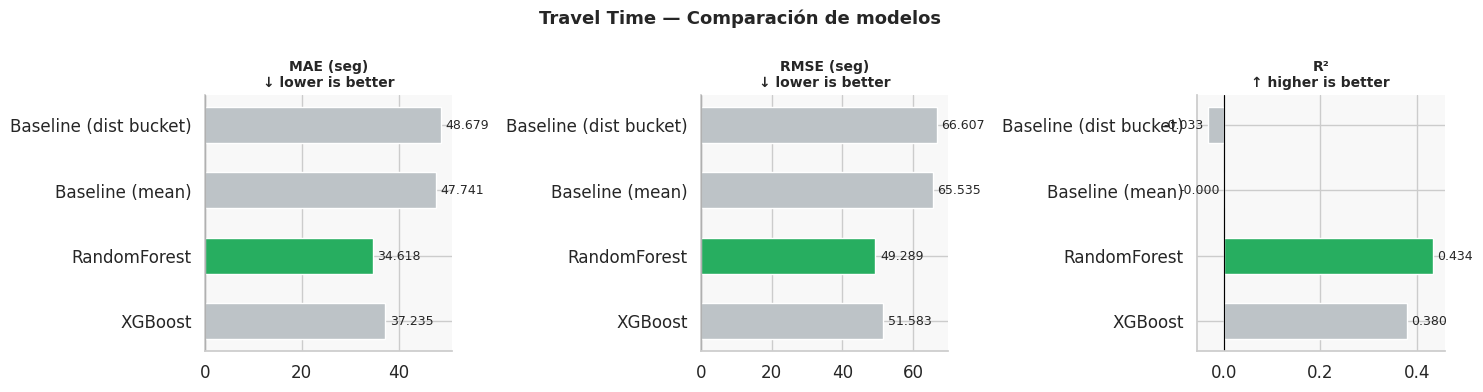

In [3]:
metrics_tt_path = OUTPUTS / "metrics_travel_time.json"
metrics_hw_path = OUTPUTS / "metrics_headway.json"

if metrics_tt_path.exists():
    with open(metrics_tt_path) as f:
        metrics_tt = json.load(f)
    df_tt = pd.DataFrame(metrics_tt["results"])
    best_tt = metrics_tt["best_model"]

    palette = ["#27ae60" if m == best_tt else "#bdc3c7" for m in df_tt["model"]]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Travel Time — Comparación de modelos", fontsize=13, fontweight="bold")

    hints = {"MAE": "↓ lower is better", "RMSE": "↓ lower is better", "R2": "↑ higher is better"}
    for ax, metric, label in zip(axes,
                                  ["MAE", "RMSE", "R2"],
                                  ["MAE (seg)", "RMSE (seg)", "R²"]):
        vals = df_tt[metric]
        bars = ax.barh(df_tt["model"], vals, color=palette, edgecolor="white", height=0.55)
        ax.set_title(f"{label}\n{hints[metric]}", fontsize=10, fontweight="bold")
        ax.axvline(0, color="black", linewidth=0.8)
        for bar, val in zip(bars, vals):
            ha = "left" if val >= 0 else "right"
            offset = abs(vals.max()) * 0.02
            x = bar.get_width() + offset if val >= 0 else bar.get_width() - offset
            ax.text(x, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", ha=ha, fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠ metrics_travel_time.json no encontrado.")


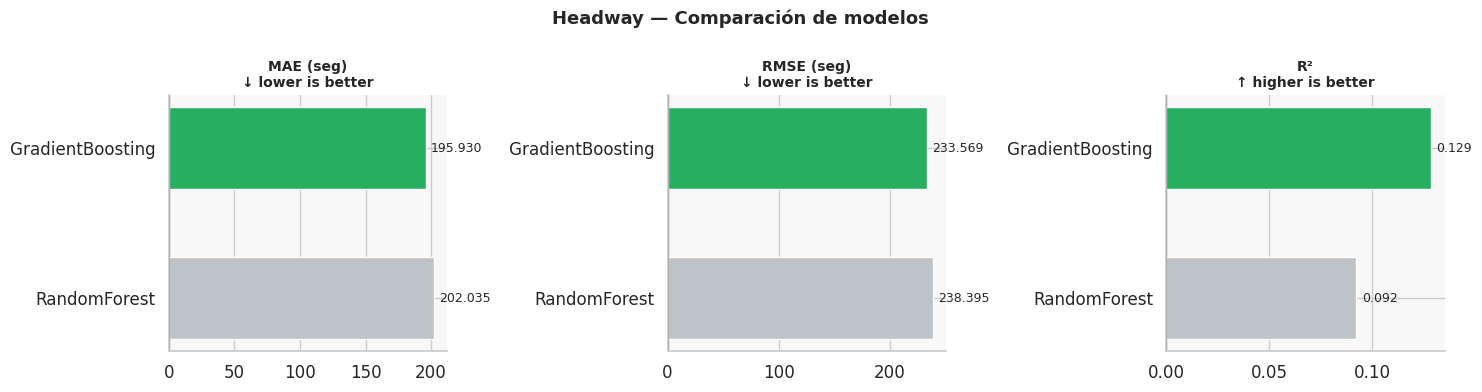

In [4]:
if metrics_hw_path.exists():
    with open(metrics_hw_path) as f:
        metrics_hw = json.load(f)
    df_hw = pd.DataFrame(metrics_hw["results"])
    df_hw = df_hw[~df_hw["model"].str.contains("GTFS")].reset_index(drop=True)
    best_hw = metrics_hw["best_model"]

    palette_hw = ["#27ae60" if m == best_hw else "#bdc3c7" for m in df_hw["model"]]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    fig.suptitle("Headway — Comparación de modelos", fontsize=13, fontweight="bold")

    hints = {"MAE": "↓ lower is better", "RMSE": "↓ lower is better", "R2": "↑ higher is better"}
    for ax, metric, label in zip(axes,
                                  ["MAE", "RMSE", "R2"],
                                  ["MAE (seg)", "RMSE (seg)", "R²"]):
        vals = df_hw[metric]
        bars = ax.barh(df_hw["model"], vals, color=palette_hw, edgecolor="white", height=0.55)
        ax.set_title(f"{label}\n{hints[metric]}", fontsize=10, fontweight="bold")
        ax.axvline(0, color="black", linewidth=0.8)
        for bar, val in zip(bars, vals):
            ha = "left" if val >= 0 else "right"
            offset = abs(vals.max()) * 0.02
            x = bar.get_width() + offset if val >= 0 else bar.get_width() - offset
            ax.text(x, bar.get_y() + bar.get_height() / 2,
                    f"{val:.3f}", va="center", ha=ha, fontsize=9)

    plt.tight_layout()
    plt.show()
else:
    print("⚠ metrics_headway.json no encontrado.")


### Selección de Hiperparámetros — GridSearch

Para cada modelo se realizó una búsqueda exhaustiva de hiperparámetros con validación cruzada 3-fold (`GridSearchCV`). Los heatmaps muestran el RMSE promedio de validación para cada combinación de parámetros — cuanto más oscuro/verde, mejor.

El marcador `★` indica la combinación ganadora.

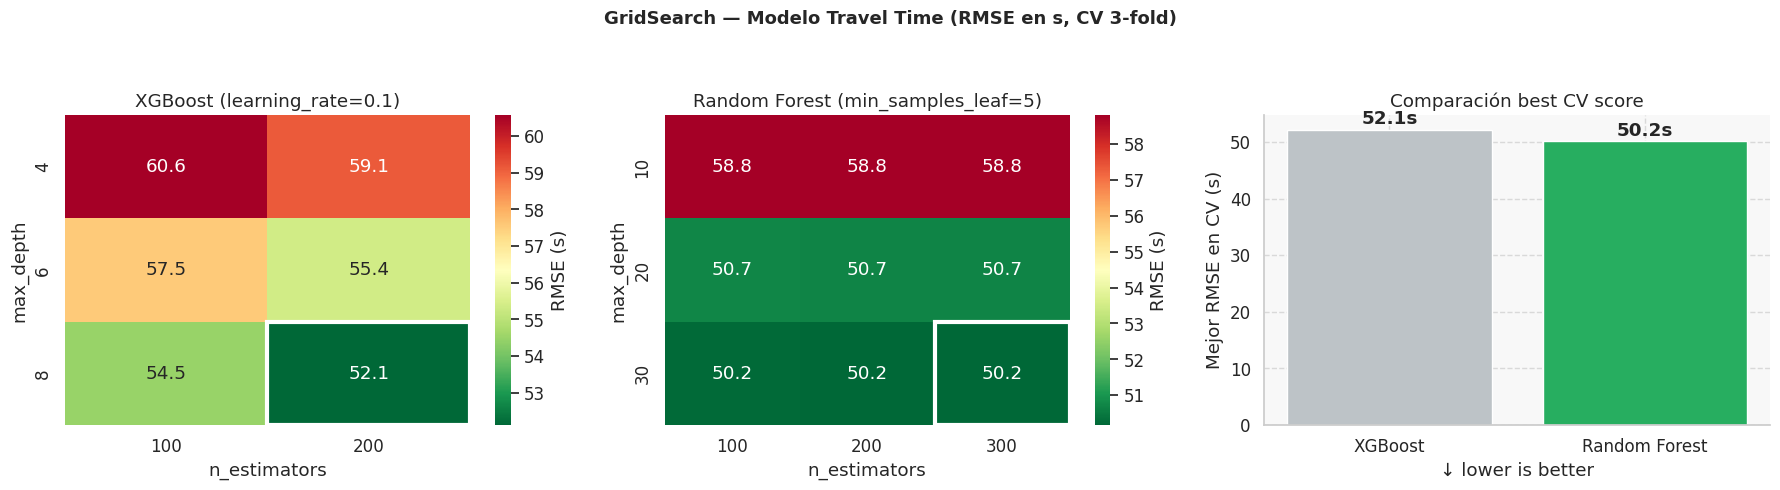

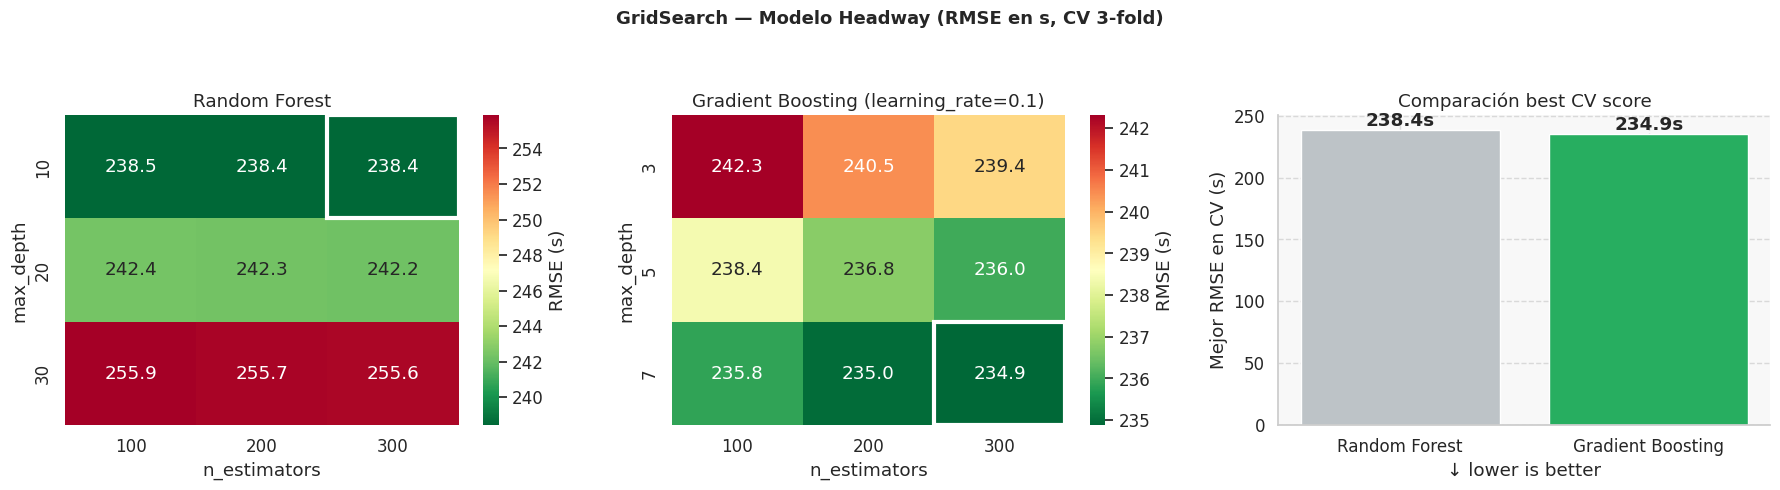

In [5]:
def plot_gridsearch_heatmap(cv_results, param_x, param_y, best_params, title, ax, param_z=None, z_val=None):
    """Heatmap de RMSE promedio de CV para dos hiperparámetros."""
    df = pd.DataFrame(cv_results)
    df["rmse"] = -df["mean_test_score"]

    col_x = f"param_{param_x}"
    col_y = f"param_{param_y}"
    if col_x not in df.columns or col_y not in df.columns:
        ax.text(0.5, 0.5, "No hay datos de GridSearch", ha="center", transform=ax.transAxes)
        return

    if param_z and f"param_{param_z}" in df.columns:
        df = df[df[f"param_{param_z}"] == z_val]

    pivot = df.pivot_table(values="rmse", index=col_y, columns=col_x, aggfunc="min")
    pivot.index = [str(v) for v in pivot.index]
    pivot.columns = [str(v) for v in pivot.columns]

    sns.heatmap(pivot, annot=True, fmt=".1f", cmap="RdYlGn_r", ax=ax, cbar_kws={"label": "RMSE (s)"})
    ax.set_xlabel(param_x)
    ax.set_ylabel(param_y)
    ax.set_title(title)

    best_x = str(best_params.get(param_x, ""))
    best_y = str(best_params.get(param_y, ""))
    if best_x in pivot.columns.tolist() and best_y in pivot.index.tolist():
        col_idx = pivot.columns.tolist().index(best_x)
        row_idx = pivot.index.tolist().index(best_y)
        from matplotlib.patches import Rectangle as _Rect
        ax.add_patch(_Rect((col_idx, row_idx), 1, 1,
                           fill=False, edgecolor="white", linewidth=3, zorder=5))


model_tt_path = OUTPUTS / "model_travel_time.joblib"
model_hw_path = OUTPUTS / "model_headway.joblib"

# --- Travel Time: XGBoost y Random Forest ---
if model_tt_path.exists():
    bundle_tt = joblib.load(model_tt_path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("GridSearch — Modelo Travel Time (RMSE en s, CV 3-fold)", fontsize=13, fontweight="bold")

    # XGBoost: n_estimators vs max_depth (con mejor learning_rate fijo)
    if "cv_results_xgb" in bundle_tt:
        best_lr = bundle_tt["best_params_xgb"].get("learning_rate")
        plot_gridsearch_heatmap(
            bundle_tt["cv_results_xgb"],
            param_x="n_estimators", param_y="max_depth",
            best_params=bundle_tt["best_params_xgb"],
            title=f"XGBoost (learning_rate={best_lr})",
            ax=axes[0], param_z="learning_rate", z_val=best_lr
        )
    else:
        axes[0].text(0.5, 0.5, "cv_results_xgb no disponible\n(re-entrena con script 04)", ha="center", va="center", transform=axes[0].transAxes)
        axes[0].set_title("XGBoost")

    # Random Forest: n_estimators vs max_depth (con mejor min_samples_leaf fijo)
    if "cv_results_rf" in bundle_tt:
        best_msl = bundle_tt["best_params_rf"].get("min_samples_leaf")
        plot_gridsearch_heatmap(
            bundle_tt["cv_results_rf"],
            param_x="n_estimators", param_y="max_depth",
            best_params=bundle_tt["best_params_rf"],
            title=f"Random Forest (min_samples_leaf={best_msl})",
            ax=axes[1], param_z="min_samples_leaf", z_val=best_msl
        )
    else:
        axes[1].text(0.5, 0.5, "cv_results_rf no disponible\n(re-entrena con script 04)", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Random Forest")

    # Comparación final de modelos
    if "cv_results_xgb" in bundle_tt and "cv_results_rf" in bundle_tt:
        xgb_best = -max(bundle_tt["cv_results_xgb"]["mean_test_score"])
        rf_best = -max(bundle_tt["cv_results_rf"]["mean_test_score"])
        models = ["XGBoost", "Random Forest"]
        vals = [xgb_best, rf_best]
        winner_tt = models[vals.index(min(vals))]
        colors = ["#27ae60" if m == winner_tt else "#bdc3c7" for m in models]
        bars = axes[2].bar(models, vals, color=colors, edgecolor="white")
        for bar, val in zip(bars, vals):
            axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.3, f"{val:.1f}s",
                         ha="center", va="bottom", fontweight="bold")
        axes[2].set_ylabel("Mejor RMSE en CV (s)")
        axes[2].set_title("Comparación best CV score")
        add_grid(axes[2])
        winner = models[vals.index(min(vals))]
        axes[2].set_xlabel("↓ lower is better")
    else:
        axes[2].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
else:
    print("⚠ model_travel_time.joblib no encontrado. Ejecutar script 04.")

# --- Headway: Random Forest y Gradient Boosting ---
if model_hw_path.exists():
    bundle_hw = joblib.load(model_hw_path)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("GridSearch — Modelo Headway (RMSE en s, CV 3-fold)", fontsize=13, fontweight="bold")

    # Random Forest: n_estimators vs max_depth
    if "cv_results_rf" in bundle_hw:
        plot_gridsearch_heatmap(
            bundle_hw["cv_results_rf"],
            param_x="n_estimators", param_y="max_depth",
            best_params=bundle_hw["best_params_rf"],
            title="Random Forest",
            ax=axes[0]
        )
    else:
        axes[0].text(0.5, 0.5, "cv_results_rf no disponible\n(re-entrena con script 05)", ha="center", va="center", transform=axes[0].transAxes)
        axes[0].set_title("Random Forest")

    # GradientBoosting: n_estimators vs max_depth (con mejor learning_rate fijo)
    if "cv_results_gb" in bundle_hw:
        best_lr = bundle_hw["best_params_gb"].get("learning_rate")
        plot_gridsearch_heatmap(
            bundle_hw["cv_results_gb"],
            param_x="n_estimators", param_y="max_depth",
            best_params=bundle_hw["best_params_gb"],
            title=f"Gradient Boosting (learning_rate={best_lr})",
            ax=axes[1], param_z="learning_rate", z_val=best_lr
        )
    else:
        axes[1].text(0.5, 0.5, "cv_results_gb no disponible\n(re-entrena con script 05)", ha="center", va="center", transform=axes[1].transAxes)
        axes[1].set_title("Gradient Boosting")

    # Comparación final
    if "cv_results_rf" in bundle_hw and "cv_results_gb" in bundle_hw:
        rf_best = -max(bundle_hw["cv_results_rf"]["mean_test_score"])
        gb_best = -max(bundle_hw["cv_results_gb"]["mean_test_score"])
        models = ["Random Forest", "Gradient Boosting"]
        vals = [rf_best, gb_best]
        winner_hw = models[vals.index(min(vals))]
        colors = ["#27ae60" if m == winner_hw else "#bdc3c7" for m in models]
        bars = axes[2].bar(models, vals, color=colors, edgecolor="white")
        for bar, val in zip(bars, vals):
            axes[2].text(bar.get_x() + bar.get_width()/2, val + 0.3, f"{val:.1f}s",
                         ha="center", va="bottom", fontweight="bold")
        axes[2].set_ylabel("Mejor RMSE en CV (s)")
        axes[2].set_title("Comparación best CV score")
        add_grid(axes[2])
        winner = models[vals.index(min(vals))]
        axes[2].set_xlabel("↓ lower is better")
    else:
        axes[2].axis("off")

    plt.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()
else:
    print("⚠ model_headway.joblib no encontrado. Ejecutar script 05.")

## Métricas y visualización

Feature Importance — Travel Time Model


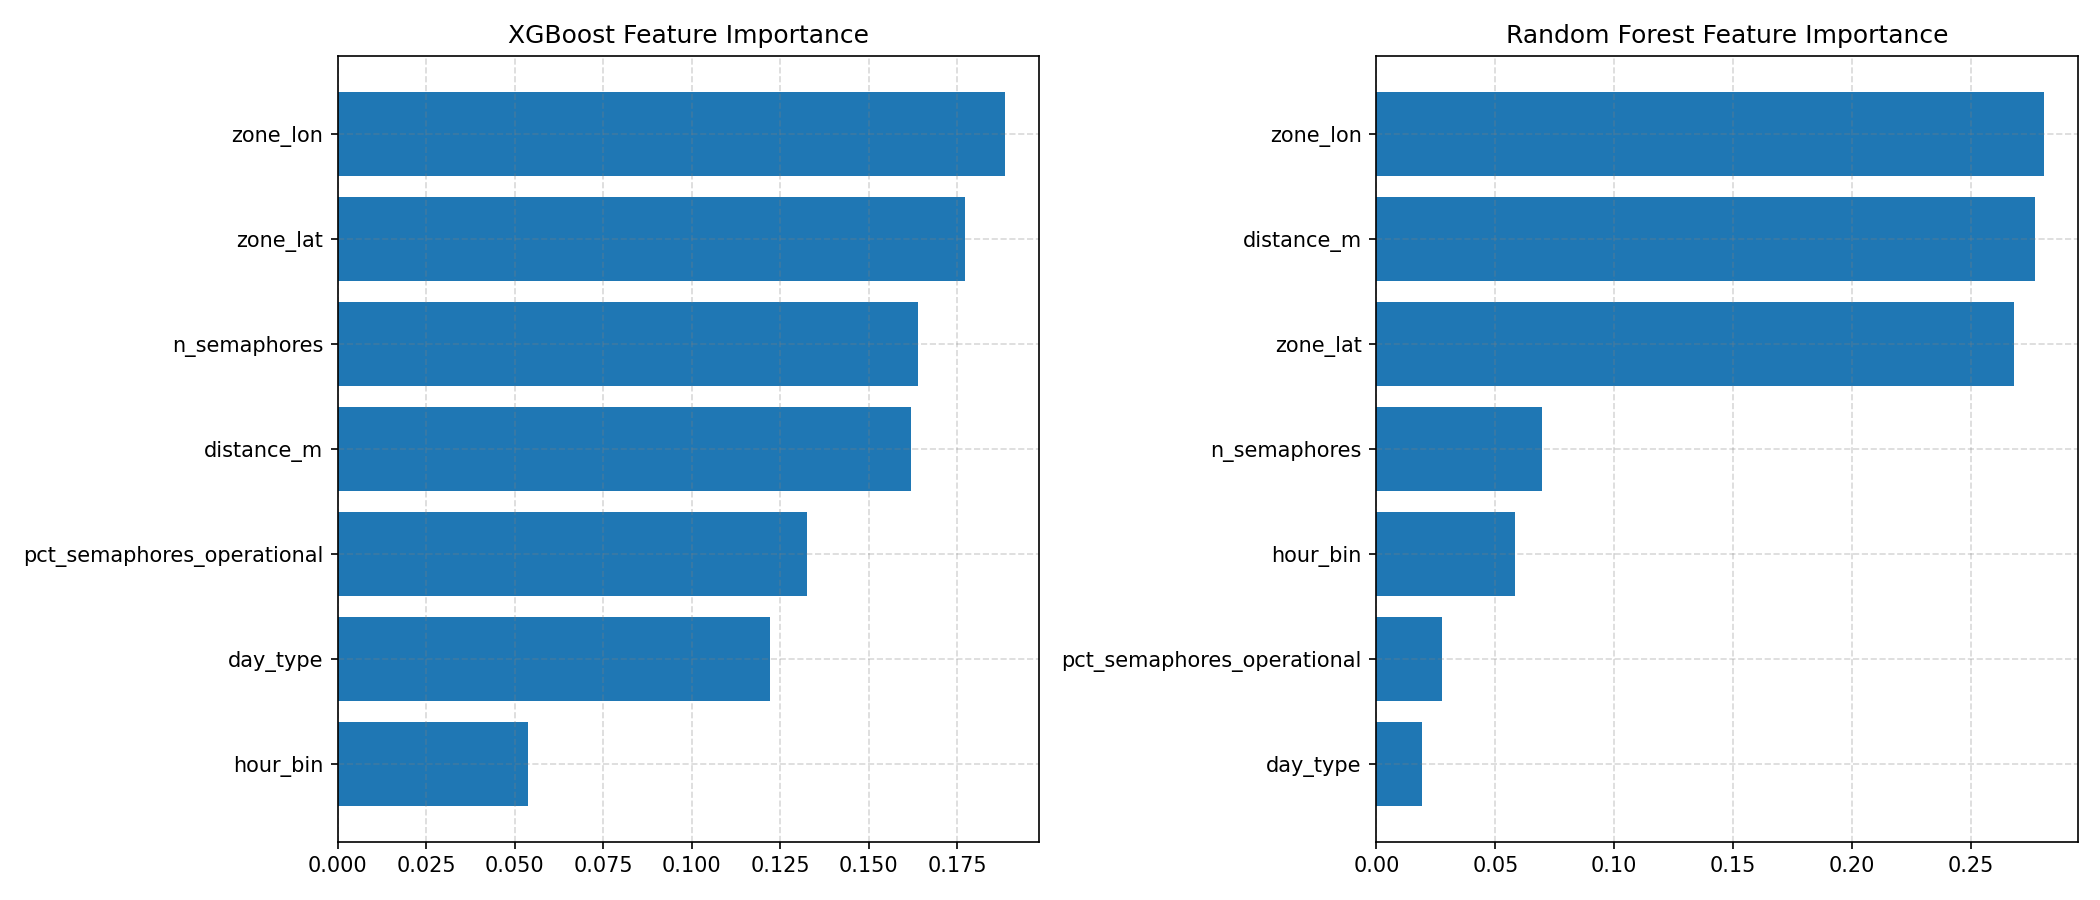

In [6]:
fi_tt_path = OUTPUTS / "feature_importance_travel_time.png"
fi_hw_path = OUTPUTS / "feature_importance_headway.png"

if fi_tt_path.exists():
    from IPython.display import Image, display
    print("Feature Importance — Travel Time Model")
    display(Image(filename=str(fi_tt_path)))
else:
    print("⚠ feature_importance_travel_time.png no encontrado.")

Feature Importance — Headway Model


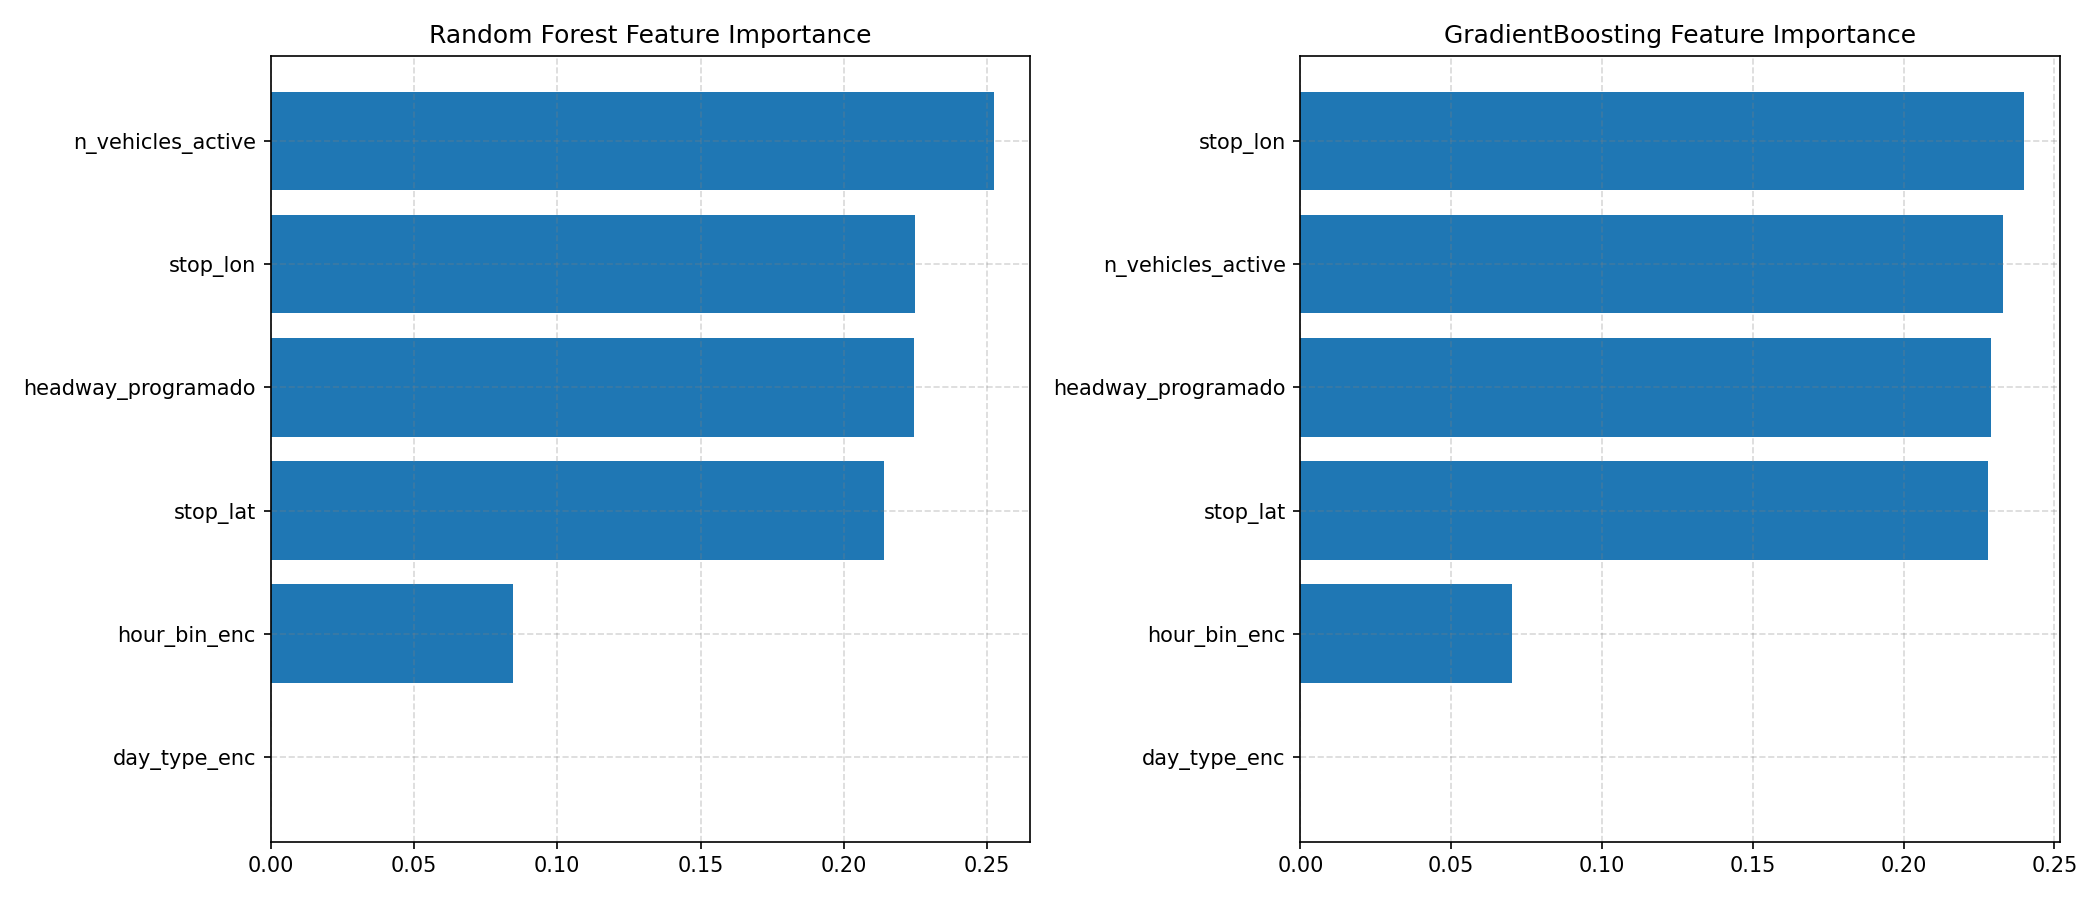

In [7]:
if fi_hw_path.exists():
    from IPython.display import Image, display
    print("Feature Importance — Headway Model")
    display(Image(filename=str(fi_hw_path)))
else:
    print("⚠ feature_importance_headway.png no encontrado.")

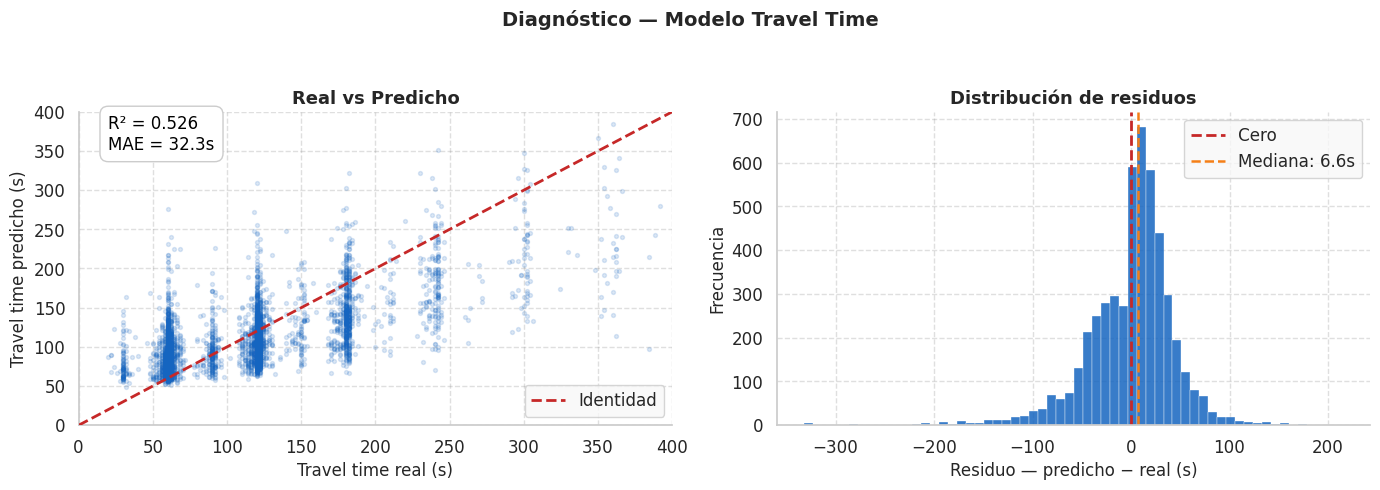

In [8]:
if not segments_feat.empty and metrics_tt_path.exists():
    model_tt = joblib.load(OUTPUTS / "model_travel_time.joblib")
    features = model_tt["features"]
    feat_df  = segments_feat.dropna(subset=features + ["travel_time_observed"]).copy()
    feat_df  = feat_df[feat_df["travel_time_observed"] <= 600]

    hour_map = {"early_morning":0,"morning_peak":1,"midday":2,"evening_peak":3,"night":4}
    day_map  = {"weekday":0,"weekend":1}
    if "hour_bin" in feat_df.columns:
        feat_df["hour_bin"] = feat_df["hour_bin"].map(hour_map).fillna(2)
    if "day_type" in feat_df.columns:
        feat_df["day_type"] = feat_df["day_type"].map(day_map).fillna(0)

    avail  = [c for c in features if c in feat_df.columns]
    sample = feat_df.sample(min(5000, len(feat_df)), random_state=42)
    preds  = model_tt["model"].predict(sample[avail].values)
    y_s    = sample["travel_time_observed"].values

    from sklearn.metrics import r2_score, mean_absolute_error
    r2  = r2_score(y_s, preds)
    mae = mean_absolute_error(y_s, preds)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    max_val = 400

    # scatter con alpha — contraste alto, sin fondo claro sobre claro
    axes[0].scatter(y_s, preds, alpha=0.15, s=8, color="#1565C0", rasterized=True)
    axes[0].plot([0, max_val], [0, max_val], "--", color=PALETTE["danger"],
                 linewidth=2, label="Identidad", zorder=5)
    axes[0].set_facecolor("white")
    axes[0].set_xlabel("Travel time real (s)", fontsize=12)
    axes[0].set_ylabel("Travel time predicho (s)", fontsize=12)
    axes[0].set_title("Real vs Predicho", fontsize=13, fontweight="bold")
    axes[0].set_xlim(0, max_val); axes[0].set_ylim(0, max_val)
    axes[0].legend()
    axes[0].text(0.05, 0.88,
                 f"R² = {r2:.3f}\nMAE = {mae:.1f}s",
                 transform=axes[0].transAxes, fontsize=12, color="black",
                 bbox=dict(boxstyle="round,pad=0.5", facecolor="white",
                           edgecolor="#cccccc", alpha=1.0))
    add_grid(axes[0])

    residuals = preds - y_s
    axes[1].set_facecolor("white")
    axes[1].hist(residuals, bins=60, color=PALETTE["primary"],
                 edgecolor="white", linewidth=0.3, alpha=0.85)
    axes[1].axvline(0, color=PALETTE["danger"], linestyle="--",
                    linewidth=2, label="Cero")
    axes[1].axvline(np.median(residuals), color="#F57F17", linestyle="--",
                    linewidth=1.8, label=f"Mediana: {np.median(residuals):.1f}s")
    axes[1].set_xlabel("Residuo — predicho − real (s)", fontsize=12)
    axes[1].set_ylabel("Frecuencia", fontsize=12)
    axes[1].set_title("Distribución de residuos", fontsize=13, fontweight="bold")
    axes[1].legend()
    add_grid(axes[1])

    plt.suptitle("Diagnóstico — Modelo Travel Time",
                 fontsize=14, fontweight="bold")
    plt.tight_layout(rect=[0, 0, 1, 0.94])
    plt.show()
else:
    print("No hay datos suficientes.")


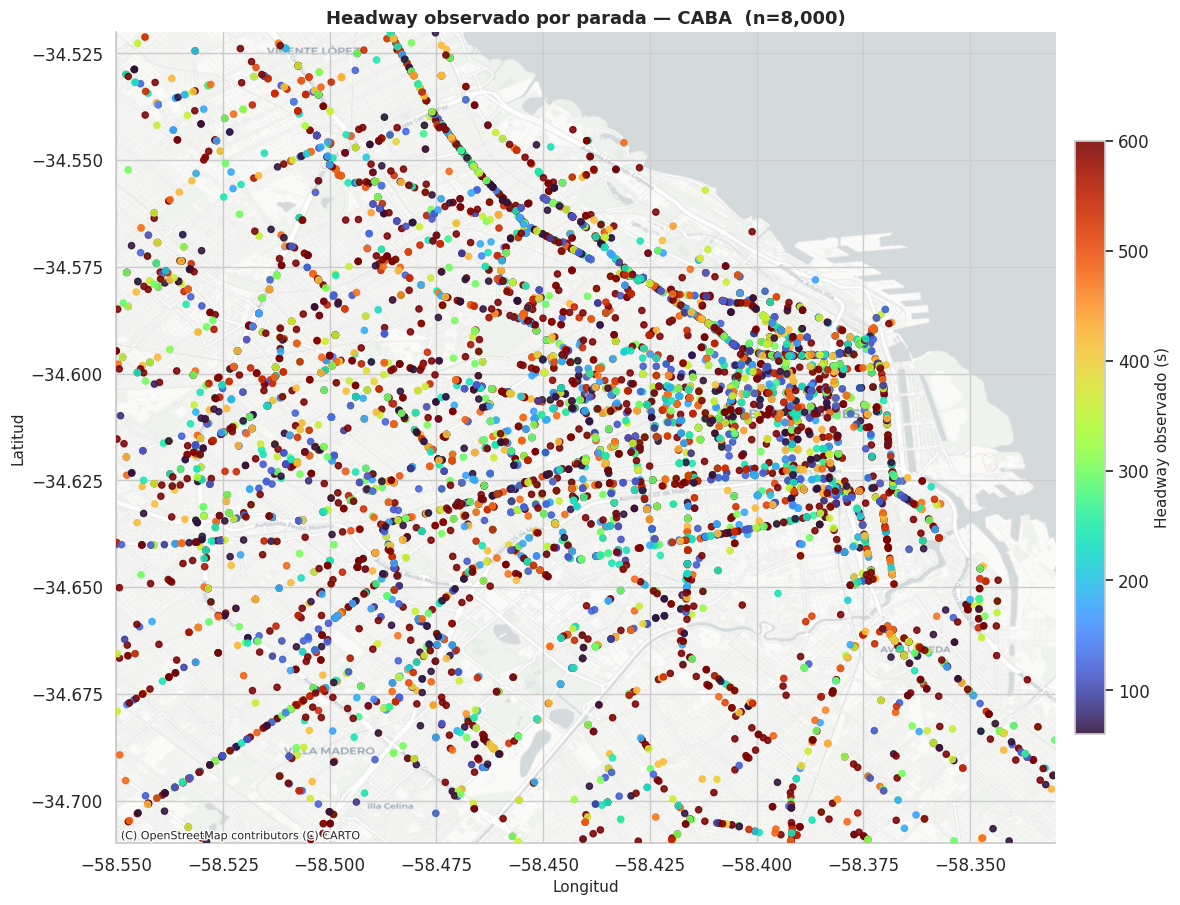

In [9]:
if not headway_feat.empty:
    hw = headway_feat.dropna(subset=["headway_observed"])
    hw = hw[hw["headway_observed"] <= 900]
    if "stop_lat" in hw.columns and "stop_lon" in hw.columns:
        CABA_LAT = (-34.71, -34.52)
        CABA_LON = (-58.55, -58.33)
        hw_caba  = hw[hw["stop_lat"].between(*CABA_LAT) & hw["stop_lon"].between(*CABA_LON)]
        sample_hw = hw_caba.sample(min(8000, len(hw_caba)), random_state=42)

        fig, ax = plt.subplots(figsize=(12, 12))
        sc = ax.scatter(
            sample_hw["stop_lon"], sample_hw["stop_lat"],
            c=sample_hw["headway_observed"], cmap="turbo",
            s=20, alpha=0.88, vmin=60, vmax=600, zorder=3,
        )
        cb = plt.colorbar(sc, ax=ax, fraction=0.03, pad=0.02)
        cb.set_label("Headway observado (s)", fontsize=11)

        import contextily as cx
        cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron, zoom=13)

        ax.set_xlim(*CABA_LON); ax.set_ylim(*CABA_LAT)
        ax.set_xlabel("Longitud", fontsize=11)
        ax.set_ylabel("Latitud",  fontsize=11)
        ax.set_title(f"Headway observado por parada — CABA  (n={len(sample_hw):,})",
                     fontsize=13, fontweight="bold")
        ax.set_aspect("equal")
        plt.tight_layout()
        plt.show()
    else:
        print("No hay coordenadas de parada en headway features.")
else:
    print("No hay datos de headway features.")


In [10]:
route_scores = load_parquet("route_scores.parquet")
if not route_scores.empty:
    print("=== Eficiencia de rutas ===")
    print(f"Rutas analizadas: {len(route_scores)}")
    print(f"\nTop 10 peores rutas:")
    cols = ["route_short_name", "spatial_deviation_m", "temporal_deviation_pct", "efficiency_score"]
    print(route_scores.head(10)[[c for c in cols if c in route_scores.columns]].to_string(index=False))
    print(f"\nTop 10 mejores rutas:")
    print(route_scores.tail(10).iloc[::-1][[c for c in cols if c in route_scores.columns]].to_string(index=False))
else:
    print("⚠ route_scores.parquet no encontrado.")

    # Visualización top-20 peores rutas
    if "efficiency_score" in route_scores.columns and len(route_scores) > 0:
        top20 = route_scores.head(20).copy().sort_values("efficiency_score")
        fig, ax = plt.subplots(figsize=(10, 7))
        bar_colors = [PALETTE["danger"] if i >= len(top20)-5 else PALETTE["primary"]
                      for i in range(len(top20))]
        bars = ax.barh(top20["route_short_name"], top20["efficiency_score"],
                       color=bar_colors, alpha=0.85)
        ax.bar_label(bars, fmt="%.0f", padding=4, fontsize=9)
        ax.set_xlabel("Efficiency Score (mayor = peor)", fontsize=11)
        ax.set_title("Top 20 rutas con peor eficiencia", fontsize=13, fontweight="bold")
        ax.invert_yaxis()
        add_grid(ax)
        plt.tight_layout()
        plt.show()


=== Eficiencia de rutas ===
Rutas analizadas: 400

Top 10 peores rutas:
route_short_name  spatial_deviation_m  temporal_deviation_pct  efficiency_score
            318B        131057.526442              333.273092      68861.494144
            202D        116660.181545              304.799197      61378.082740
            101B        112608.808151              333.564257      59640.046646
         506R80A         92513.088177              250.933735      48765.881438
           520CB         88691.935468              251.777108      46863.738818
          214B64         83185.959659              151.104418      43104.024006
         506R80A         78276.322353              333.554217      42473.703345
           247R7         75220.492670              407.540161      41685.647941
          214B64         77082.962552              144.447791      39985.959188
           520CB         68615.413892              346.797189      37775.678833

Top 10 mejores rutas:
route_short_name  spatial

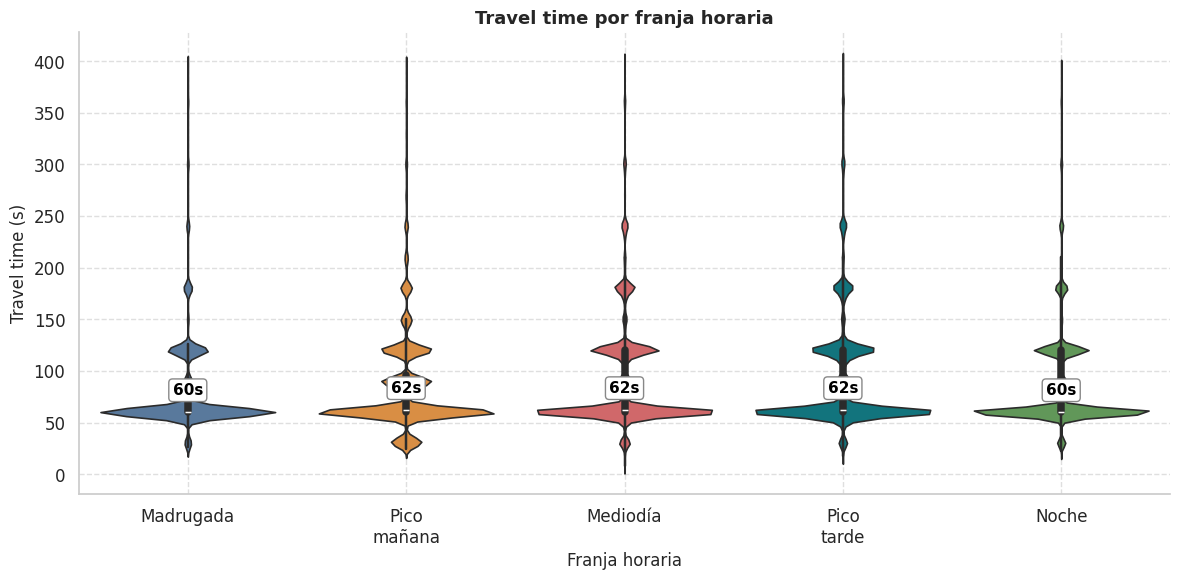

In [11]:
if not segments_feat.empty and "hour_bin" in segments_feat.columns:
    order  = ["early_morning","morning_peak","midday","evening_peak","night"]
    labels = {
        "early_morning":"Madrugada","morning_peak":"Pico\nmañana",
        "midday":"Mediodía","evening_peak":"Pico\ntarde","night":"Noche",
    }
    existing = [h for h in order if h in segments_feat["hour_bin"].unique()]
    if existing:
        plot_data = (segments_feat[segments_feat["hour_bin"].isin(existing)
                                    & (segments_feat["travel_time_observed"] <= 400)]
                     .copy())
        plot_data["hora"] = plot_data["hour_bin"].map(labels)
        hora_order = [labels[h] for h in existing]

        # paleta con colores distintos (no gradiente)
        palette = ["#4E79A7","#F28E2B","#E15759","#00838F","#59A14F"][:len(existing)]

        fig, ax = plt.subplots(figsize=(12, 6))
        ax.set_facecolor("white")
        sns.violinplot(data=plot_data, x="hora", y="travel_time_observed",
                       order=hora_order, palette=palette, inner="box",
                       linewidth=1.2, ax=ax)

        medians = plot_data.groupby("hora")["travel_time_observed"].median()
        for i, h in enumerate(hora_order):
            if h in medians:
                # label negro con caja blanca sólida — siempre legible
                ax.text(i, medians[h] + 14, f"{medians[h]:.0f}s",
                        ha="center", va="bottom", fontsize=11,
                        fontweight="bold", color="black",
                        bbox=dict(boxstyle="round,pad=0.25",
                                  facecolor="white", edgecolor="#888",
                                  alpha=1.0), clip_on=False)

        ax.set_xlabel("Franja horaria", fontsize=12)
        ax.set_ylabel("Travel time (s)", fontsize=12)
        ax.set_title("Travel time por franja horaria", fontsize=13, fontweight="bold")
        add_grid(ax)
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de hour_bin para visualizar.")
else:
    print("No hay datos de segmentos features.")


## Simulador de rutas

1. Toma la **peor ruta** por eficiencia y detecta **zonas congestionadas** (travel time > p85 para la distancia recorrida)
2. Busca camino alternativo en un **grafo de todas las paradas de la zona**, con pesos = travel time observado
3. Valida que gaps entre paradas no superen 500m; agrega paradas intermedias de otras líneas si hace falta
4. Calcula el **ahorro total** respecto a la ruta original

In [12]:
import sys, networkx as nx
from scipy.spatial import cKDTree
sys.path.insert(0, str(Path('../scripts').resolve()))
from utils import haversine_m
from osrm_routing import is_osrm_available, get_route

MAX_GAP_M = 500
MEDIAN_SPEED = 4.6

sf = load_parquet('segments_features.parquet')
if sf.empty:
    print('Run scripts 01-03 first.')
else:
    route_scores_loaded = load_parquet('route_scores.parquet')
    if not route_scores_loaded.empty:
        worst_route = route_scores_loaded.iloc[0]['route_short_name']
    else:
        worst_route = sf['route_short_name'].value_counts().index[0]

    r_data = sf[(sf['route_short_name'] == worst_route) & sf['stop_A_lat'].notna()]
    if r_data.empty:
        worst_route = sf['route_short_name'].value_counts().index[0]
        r_data = sf[(sf['route_short_name'] == worst_route) & sf['stop_A_lat'].notna()]

    use_osrm = is_osrm_available()
    print(f'OSRM: {"Disponible (calles reales)" if use_osrm else "No disponible (haversine)"}')

    best_trip = r_data.groupby('trip_id').size().sort_values(ascending=False).index[0]
    trip_data = r_data[r_data['trip_id'] == best_trip]

    stops_seq = trip_data.groupby('arrival_seq').agg(
        stop_id=('stop_id_A', 'first'), lat=('stop_A_lat', 'median'), lon=('stop_A_lon', 'median'),
    ).sort_index().reset_index(drop=True)

    seg_stats = trip_data[trip_data['next_seq'] == trip_data['arrival_seq'] + 1].groupby(
        'arrival_seq'
    ).agg(
        med_tt=('travel_time_observed', 'median'),
        med_dist=('distance_m', 'median'),
    ).sort_index().reset_index(drop=True)

    total_tt = seg_stats['med_tt'].sum()
    print(f'Linea {worst_route} — Trip {best_trip}')
    print(f'  {len(stops_seq)} paradas, {seg_stats["med_dist"].sum():.0f}m totales')
    print(f'  Tiempo total observado: {total_tt:.0f}s ({total_tt/60:.1f} min)')

    all_a = sf[['stop_id_A','stop_A_lat','stop_A_lon']].dropna().drop_duplicates('stop_id_A')
    all_a.columns = ['stop_id','lat','lon']
    all_b = sf[['stop_id_B','stop_B_lat','stop_B_lon']].dropna().drop_duplicates('stop_id_B')
    all_b.columns = ['stop_id','lat','lon']
    all_stops = pd.concat([all_a, all_b]).drop_duplicates('stop_id')

    bbox_lat = (stops_seq['lat'].min()-0.015, stops_seq['lat'].max()+0.015)
    bbox_lon = (stops_seq['lon'].min()-0.015, stops_seq['lon'].max()+0.015)
    nearby = all_stops[all_stops['lat'].between(*bbox_lat) & all_stops['lon'].between(*bbox_lon)]
    stop_routes = sf.dropna(subset=['stop_A_lat']).groupby('stop_id_A')[
        'route_short_name'].apply(lambda x: list(x.unique())[:5]).to_dict()

    graph_edges = sf.dropna(subset=['stop_A_lat']).groupby(['stop_id_A','stop_id_B']).agg(
        med_tt=('travel_time_observed','median'), n=('travel_time_observed','count'),
    ).reset_index()
    graph_edges = graph_edges[graph_edges['n'] >= 3]
    zone_ids = set(nearby['stop_id'])
    ze = graph_edges[graph_edges['stop_id_A'].isin(zone_ids) & graph_edges['stop_id_B'].isin(zone_ids)]

    bus_graph = nx.DiGraph()
    for _, r in ze.iterrows():
        bus_graph.add_edge(r['stop_id_A'], r['stop_id_B'], weight=r['med_tt'])

    route_stop_ids = set(stops_seq['stop_id'])
    coords = np.radians(nearby[['lat','lon']].values)
    tree = cKDTree(coords)
    radius_rad = (MAX_GAP_M * 2) / 6_371_000
    pairs = tree.query_pairs(radius_rad)
    for i, j in pairs:
        s, t = nearby.iloc[i], nearby.iloc[j]
        if s['stop_id'] in route_stop_ids and t['stop_id'] in route_stop_ids:
            continue
        if not bus_graph.has_edge(s['stop_id'], t['stop_id']):
            d = haversine_m(s['lat'], s['lon'], t['lat'], t['lon'])
            if use_osrm:
                route = get_route(s['lon'], s['lat'], t['lon'], t['lat'])
                if route:
                    bus_graph.add_edge(s['stop_id'], t['stop_id'], weight=route['duration_s'], geometry=route['geometry'])
                    bus_graph.add_edge(t['stop_id'], s['stop_id'], weight=route['duration_s'], geometry=route['geometry'])
                    continue
            bus_graph.add_edge(s['stop_id'], t['stop_id'], weight=d/MEDIAN_SPEED)
            bus_graph.add_edge(t['stop_id'], s['stop_id'], weight=d/MEDIAN_SPEED)

    print(f'  Grafo: {bus_graph.number_of_nodes()} nodos, {bus_graph.number_of_edges()} aristas')

OSRM: No disponible (haversine)
Linea 318B — Trip 78691-1
  74 paradas, 7334m totales
  Tiempo total observado: 2724s (45.4 min)
  Grafo: 1556 nodos, 125810 aristas


  Grafo: 1556 nodos, 125810 aristas


In [13]:
p90 = seg_stats['med_tt'].quantile(0.85)
total_dist = seg_stats['med_dist'].sum()
total_tt_seg = seg_stats['med_tt'].sum()
if total_tt_seg == 0:
    print('No consecutive segments found for this trip.')
    mean_speed = None
else:
    mean_speed = total_dist / total_tt_seg

zones = []
i = 0
while mean_speed and i < len(seg_stats):
    if seg_stats.iloc[i]['med_tt'] > p90:
        start = i
        while i < len(seg_stats) and seg_stats.iloc[i]['med_tt'] > p90 * 0.6:
            i += 1
        end = min(i, len(seg_stats))
        if end - start >= 1:
            zt = seg_stats.iloc[start:end]['med_tt'].sum()
            zd = seg_stats.iloc[start:end]['med_dist'].sum()
            expected = zd / mean_speed
            if zt > expected * 1.3 and zt > 120:
                zones.append({'start': start, 'end': end, 'tt': zt, 'dist': zd})
    else:
        i += 1

all_stops_map = nearby.set_index('stop_id')[['lat','lon']].to_dict('index')
proposals = []

for z in zones:
    a = stops_seq.iloc[z['start']]
    b = stops_seq.iloc[z['end']]
    try:
        path = nx.shortest_path(bus_graph, a['stop_id'], b['stop_id'], weight='weight')
        path_tt = sum(bus_graph[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
    except (nx.NetworkXNoPath, KeyError):
        path = [a['stop_id'], b['stop_id']]
        path_tt = z['tt']

    removed = [stops_seq.iloc[idx]['stop_id'] for idx in range(z['start']+1, z['end'])]
    new_stops = []
    for sid in path[1:-1]:
        info = all_stops_map.get(sid)
        if info:
            new_stops.append({'stop_id': sid, 'lat': info['lat'], 'lon': info['lon'],
                              'lines': stop_routes.get(sid, [])[:5],
                              'is_new': sid not in route_stop_ids})

    all_pts = [(a['lat'], a['lon'])]
    for ns in new_stops:
        all_pts.append((ns['lat'], ns['lon']))
    all_pts.append((b['lat'], b['lon']))

    extra = []
    for idx in range(len(all_pts)-1):
        gap = haversine_m(all_pts[idx][0], all_pts[idx][1], all_pts[idx+1][0], all_pts[idx+1][1])
        if gap > MAX_GAP_M:
            mid = ((all_pts[idx][0]+all_pts[idx+1][0])/2, (all_pts[idx][1]+all_pts[idx+1][1])/2)
            close = nearby[(abs(nearby['lat']-mid[0])<0.003) & (abs(nearby['lon']-mid[1])<0.003)
                            & (~nearby['stop_id'].isin(route_stop_ids))]
            if not close.empty:
                c = close.iloc[0]
                extra.append({'stop_id': c['stop_id'], 'lat': c['lat'], 'lon': c['lon'],
                              'lines': stop_routes.get(c['stop_id'], [])[:5], 'gap': gap})

    max_gap = max(haversine_m(all_pts[i][0], all_pts[i][1], all_pts[i+1][0], all_pts[i+1][1])
                  for i in range(len(all_pts)-1))

    _edge_geoms = [bus_graph[path[k]][path[k+1]].get('geometry') for k in range(len(path)-1)]
    if any(_edge_geoms):
        path_geometry = []
        for k, geom in enumerate(_edge_geoms):
            if geom:
                path_geometry.extend(geom)
            else:
                s_info = all_stops_map.get(path[k])
                t_info = all_stops_map.get(path[k+1])
                if s_info and t_info:
                    path_geometry.append([s_info['lon'], s_info['lat']])
                    path_geometry.append([t_info['lon'], t_info['lat']])
    else:
        from osrm_routing import get_route_waypoints, PUBLIC_OSRM_URL
        _wpts = [(all_stops_map[sid]['lon'], all_stops_map[sid]['lat'])
                 for sid in path if sid in all_stops_map]
        _res = get_route_waypoints(_wpts, osrm_url=PUBLIC_OSRM_URL, timeout=10.0) if len(_wpts) >= 2 else None
        path_geometry = _res['geometry'] if _res else [[lon, lat] for lon, lat in _wpts]

    proposals.append({
        'zone': f"seq {z['start']}->{z['end']}", 'stop_A': a['stop_id'], 'stop_B': b['stop_id'],
        'lat_A': a['lat'], 'lon_A': a['lon'], 'lat_B': b['lat'], 'lon_B': b['lon'],
        'original_tt': z['tt'], 'original_dist': z['dist'],
        'removed': removed, 'new_stops': new_stops, 'extra': extra,
        'alt_tt': path_tt, 'savings': max(0, z['tt'] - path_tt), 'max_gap': max_gap,
        'path_geometry': path_geometry,
    })

    removed_str = ', '.join(removed)
    print(f"Zona {proposals[-1]['zone']}: {a['stop_id']} -> {b['stop_id']}")
    print(f"  Problema: {z['tt']:.0f}s en {z['dist']:.0f}m")
    print(f"  Eliminar: {removed_str}")
    for ns in new_stops:
        tag = '(NUEVA)' if ns['is_new'] else ''
        lines = ', '.join(ns['lines'][:3])
        print(f"  Agregar: {ns['stop_id']}{tag} [{lines}]")
    for es in extra:
        lines = ', '.join(es['lines'][:3])
        print(f"  + Intermedia: {es['stop_id']} [{lines}] (gap {es['gap']:.0f}m)")
    print(f"  Tiempo: {z['tt']:.0f}s -> {path_tt:.0f}s (ahorro {proposals[-1]['savings']:.0f}s)")
    print()

total_savings = sum(p['savings'] for p in proposals)
print(f"AHORRO TOTAL: {total_savings:.0f}s ({total_savings/60:.1f} min) — {total_savings/total_tt*100:.1f}%")

Zona seq 35->42: 6490111429 -> 6490111412
  Problema: 526s en 1008m
  Eliminar: 6490111427, 6490111385, 6490111374, 6490111432, 6490111418, 6490111394
  Agregar: 6490111385 [318B]
  Agregar: 6490111432 [318B]
  Tiempo: 526s -> 180s (ahorro 346s)

AHORRO TOTAL: 346s (5.8 min) — 12.7%


In [14]:
if 'proposals' in dir() and proposals and len(stops_seq) > 0:
    _center = [stops_seq['lat'].mean(), stops_seq['lon'].mean()]
    _m = folium.Map(location=_center, zoom_start=14, tiles='CartoDB positron')

    _stop_wpts = [(r['lon'], r['lat']) for _, r in stops_seq.iterrows()]
    from osrm_routing import get_route_waypoints, DEFAULT_OSRM_URL, PUBLIC_OSRM_URL
    _osrm_url_r = DEFAULT_OSRM_URL if ('use_osrm' in dir() and use_osrm) else PUBLIC_OSRM_URL
    _routed_cur = get_route_waypoints(_stop_wpts, osrm_url=_osrm_url_r, timeout=20.0)
    if _routed_cur and _routed_cur.get('geometry'):
        _route_coords = [[pt[1], pt[0]] for pt in _routed_cur['geometry']]
    else:
        _route_coords = [[r['lat'], r['lon']] for _, r in stops_seq.iterrows()]
    folium.PolyLine(_route_coords, color=PALETTE['primary'], weight=5, opacity=0.65,
                    tooltip=f'Ruta actual {worst_route}').add_to(_m)
    for _, _row in stops_seq.iterrows():
        folium.CircleMarker([_row['lat'], _row['lon']], radius=4,
                            color=PALETTE['primary'], fill=True,
                            fill_color=PALETTE['primary'], fill_opacity=0.8).add_to(_m)

    for _p in proposals:
        _iA = stops_seq[stops_seq['stop_id'] == _p['stop_A']].index
        _iB = stops_seq[stops_seq['stop_id'] == _p['stop_B']].index
        if len(_iA) and len(_iB):
            _zone = stops_seq.iloc[_iA[0]:_iB[0]+1]
            folium.PolyLine([[r['lat'], r['lon']] for _, r in _zone.iterrows()],
                            color=PALETTE['danger'], weight=10, opacity=0.35,
                            tooltip='\u26a0 Zona congestionada').add_to(_m)

        for _sid in _p['removed']:
            _mr = stops_seq[stops_seq['stop_id'] == _sid]
            if not _mr.empty:
                _r = _mr.iloc[0]
                folium.CircleMarker([_r['lat'], _r['lon']], radius=9,
                                    color=PALETTE['danger'], fill=True,
                                    fill_color=PALETTE['danger'], fill_opacity=0.9,
                                    tooltip=f'\u26d4 Eliminar: {_sid}').add_to(_m)

        if _p.get('path_geometry') and len(_p['path_geometry']) > 1:
            _alt = [[pt[1], pt[0]] for pt in _p['path_geometry']]
        else:
            _alt = ([[_p['lat_A'], _p['lon_A']]]
                    + [[ns['lat'], ns['lon']] for ns in _p['new_stops']]
                    + [[es['lat'], es['lon']] for es in _p['extra']]
                    + [[_p['lat_B'], _p['lon_B']]])
        folium.PolyLine(_alt, color=PALETTE['success'], weight=5, opacity=0.9,
                        tooltip=f"\u2705 Alternativa: -{_p['savings']:.0f}s").add_to(_m)

        for _ns in _p['new_stops']:
            _c = PALETTE['success'] if _ns['is_new'] else '#42A5F5'
            folium.CircleMarker([_ns['lat'], _ns['lon']], radius=8,
                                color=_c, fill=True, fill_color=_c, fill_opacity=0.9,
                                tooltip=f"{' '.join([chr(11088)+' Nueva:'] + _ns['lines'][:2]) if _ns['is_new'] else 'existente'}").add_to(_m)
        for _es in _p['extra']:
            folium.CircleMarker([_es['lat'], _es['lon']], radius=8,
                                color=PALETTE['warning'], fill=True,
                                fill_color=PALETTE['warning'], fill_opacity=0.9,
                                tooltip=f"Intermedia: {_es['stop_id']}").add_to(_m)

        _mid_lat = (_p['lat_A'] + _p['lat_B']) / 2 + 0.001
        _mid_lon = (_p['lon_A'] + _p['lon_B']) / 2
        folium.Marker([_mid_lat, _mid_lon], icon=folium.DivIcon(
            html=(f'<div style="background:white;border:2px solid {PALETTE["success"]};'
                  f'padding:4px 8px;border-radius:5px;font-size:12px;font-weight:bold;'
                  f'color:{PALETTE["success"]};white-space:nowrap;box-shadow:1px 1px 4px #aaa">'
                  f'-{_p["savings"]:.0f}s ({_p["savings"]/60:.1f} min)</div>'),
            icon_size=(150, 28), icon_anchor=(75, 0),
        )).add_to(_m)

    _legend = f"""
    <div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;
                padding:12px 16px;border-radius:8px;border:1px solid #ccc;
                font-size:13px;line-height:2;box-shadow:2px 2px 6px #aaa">
      <b>Linea {worst_route}</b><br>
      <span style="color:{PALETTE['primary']}">&#9644;</span> Ruta actual &nbsp;
      <span style="color:{PALETTE['danger']}">&#9644;</span> Zona congestionada<br>
      <span style="color:{PALETTE['success']}">&#9644;</span> Ruta alternativa &nbsp;
      <span style="color:{PALETTE['danger']}">&#9679;</span> Eliminar &nbsp;
      <span style="color:{PALETTE['success']}">&#9679;</span> Nueva
    </div>"""
    _m.get_root().html.add_child(folium.Element(_legend))
    print(f"Linea {worst_route} | {len(proposals)} zona(s) | Ahorro total: {total_savings:.0f}s ({total_savings/60:.1f} min)")
    display(_m)
else:
    print("Ejecutar celda anterior primero.")


Linea 318B | 1 zona(s) | Ahorro total: 346s (5.8 min)


In [15]:
if 'proposals' in dir() and proposals:
    for _p in proposals[:4]:
        _lats = ([_p['lat_A'], _p['lat_B']]
                 + [ns['lat'] for ns in _p['new_stops']]
                 + [es['lat'] for es in _p['extra']])
        _lons = ([_p['lon_A'], _p['lon_B']]
                 + [ns['lon'] for ns in _p['new_stops']]
                 + [es['lon'] for es in _p['extra']])
        _center = [np.mean(_lats), np.mean(_lons)]
        _mz = folium.Map(location=_center, zoom_start=16, tiles='CartoDB positron')

        _mg = 0.006
        _nearby = stops_seq[
            stops_seq['lat'].between(min(_lats)-_mg, max(_lats)+_mg) &
            stops_seq['lon'].between(min(_lons)-_mg, max(_lons)+_mg)
        ]
        if len(_nearby) > 1:
            folium.PolyLine([[r['lat'], r['lon']] for _, r in _nearby.iterrows()],
                            color=PALETTE['primary'], weight=5, opacity=0.5).add_to(_mz)

        _iA = stops_seq[stops_seq['stop_id'] == _p['stop_A']].index
        _iB = stops_seq[stops_seq['stop_id'] == _p['stop_B']].index
        if len(_iA) and len(_iB):
            _zone = stops_seq.iloc[_iA[0]:_iB[0]+1]
            folium.PolyLine([[r['lat'], r['lon']] for _, r in _zone.iterrows()],
                            color=PALETTE['danger'], weight=10, opacity=0.4).add_to(_mz)

        for _sid in _p['removed']:
            _mr = stops_seq[stops_seq['stop_id'] == _sid]
            if not _mr.empty:
                _r = _mr.iloc[0]
                folium.CircleMarker([_r['lat'], _r['lon']], radius=11,
                                    color=PALETTE['danger'], fill=True,
                                    fill_color=PALETTE['danger'], fill_opacity=0.9,
                                    tooltip=f'\u26d4 {_sid}').add_to(_mz)

        if _p.get('path_geometry') and len(_p['path_geometry']) > 1:
            _alt = [[pt[1], pt[0]] for pt in _p['path_geometry']]
        else:
            _alt = ([[_p['lat_A'], _p['lon_A']]]
                    + [[ns['lat'], ns['lon']] for ns in _p['new_stops']]
                    + [[es['lat'], es['lon']] for es in _p['extra']]
                    + [[_p['lat_B'], _p['lon_B']]])
        folium.PolyLine(_alt, color=PALETTE['success'], weight=6, opacity=0.95).add_to(_mz)

        for _ns in _p['new_stops']:
            _c = PALETTE['success'] if _ns['is_new'] else '#42A5F5'
            folium.CircleMarker([_ns['lat'], _ns['lon']], radius=9,
                                color=_c, fill=True, fill_color=_c, fill_opacity=0.95,
                                tooltip=f"{chr(11088)+' '+', '.join(_ns['lines'][:2]) if _ns['is_new'] else 'existente'}").add_to(_mz)
        for _es in _p['extra']:
            folium.CircleMarker([_es['lat'], _es['lon']], radius=9,
                                color=PALETTE['warning'], fill=True,
                                fill_color=PALETTE['warning'], fill_opacity=0.95,
                                tooltip=f"Intermedia: {_es['stop_id']}").add_to(_mz)

        print(f"Zona {_p['zone']} | TT: {_p['original_tt']:.0f}s \u2192 {_p['alt_tt']:.0f}s | Ahorro: {_p['savings']:.0f}s ({_p['savings']/60:.1f} min)")
        display(_mz)
else:
    print("Sin propuestas para zoom.")


Zona seq 35->42 | TT: 526s → 180s | Ahorro: 346s (5.8 min)


In [16]:
if proposals:
    rows = []
    for p in proposals:
        n_removed = len(p['removed'])
        n_new = len([ns for ns in p['new_stops'] if ns['is_new']])
        n_extra = len(p['extra'])
        new_lines = set()
        for ns in p['new_stops']:
            new_lines.update(ns['lines'][:2])
        for es in p['extra']:
            new_lines.update(es['lines'][:2])
        rows.append({
            'Zona': p['zone'],
            'TT original': f"{p['original_tt']:.0f}s",
            'Distancia': f"{p['original_dist']:.0f}m",
            'Paradas eliminadas': n_removed,
            'Paradas nuevas': n_new + n_extra,
            'Lineas alternativas': ', '.join(sorted(new_lines)[:5]),
            'TT alternativa': f"{p['alt_tt']:.0f}s",
            'Ahorro': f"{p['savings']:.0f}s ({p['savings']/60:.1f}min)",
        })
    summary_df = pd.DataFrame(rows)
    print('=== Resumen de propuestas ===')
    print(summary_df.to_string(index=False))
    print(f"\nAhorro total: {total_savings:.0f}s ({total_savings/60:.1f} min) — {total_savings/total_tt*100:.1f}%")
else:
    print('Sin propuestas.')

=== Resumen de propuestas ===
      Zona TT original Distancia  Paradas eliminadas  Paradas nuevas Lineas alternativas TT alternativa        Ahorro
seq 35->42        526s     1008m                   6               0                318B           180s 346s (5.8min)

Ahorro total: 346s (5.8 min) — 12.7%


## Evaluación Holdout — Rutas no vistas

- **20 rutas** al azar de las ~566 de CABA, **no incluidas en training**
- Mismo feature engineering, modelo sin re-entrenar → mide generalización a rutas nuevas

In [17]:
holdout_metrics_path = OUTPUTS / "metrics_holdout.json"
holdout_segs_path = OUTPUTS / "holdout_segments.parquet"
holdout_diag_path = OUTPUTS / "holdout_diagnostics.png"

if holdout_metrics_path.exists():
    with open(holdout_metrics_path) as f:
        hm = json.load(f)

    print("=== Holdout Evaluation ===")
    print(f"Rutas holdout: {len(hm['holdout_routes'])}")
    print(f"Segmentos evaluados: {hm['n_holdout_segments']:,}")
    print(f"Peor ruta holdout: {hm['worst_route']}")
    print()

    ho = hm['holdout_metrics']
    tr = hm.get('train_metrics')

    print(f"{'Set':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
    print("-" * 57)
    if tr:
        print(f"{'Train test (200 rutas)':<25} {tr['MAE']:>10.1f} {tr['RMSE']:>10.1f} {tr['R2']:>10.3f}")
    print(f"{'Holdout (20 rutas)':<25} {ho['MAE']:>10.1f} {ho['RMSE']:>10.1f} {ho['R2']:>10.3f}")
    if tr:
        diff_mae = ho['MAE'] - tr['MAE']
        diff_rmse = ho['RMSE'] - tr['RMSE']
        diff_r2 = ho['R2'] - tr['R2']
        print(f"\nDegradación: MAE {diff_mae:+.1f}s, RMSE {diff_rmse:+.1f}s, R² {diff_r2:+.3f}")
        if abs(diff_r2) < 0.1:
            print("El modelo generaliza bien a rutas no vistas.")
        else:
            print("El modelo degrada significativamente en rutas nuevas.")
else:
    print("Run scripts/08_holdout_eval.py first.")

=== Holdout Evaluation ===
Rutas holdout: 20
Segmentos evaluados: 42,401
Peor ruta holdout: 152C

Set                              MAE       RMSE         R²
---------------------------------------------------------
Train test (200 rutas)          34.6       49.3      0.434
Holdout (20 rutas)              59.1       84.0     -0.788

Degradación: MAE +24.5s, RMSE +34.7s, R² -1.223
El modelo degrada significativamente en rutas nuevas.


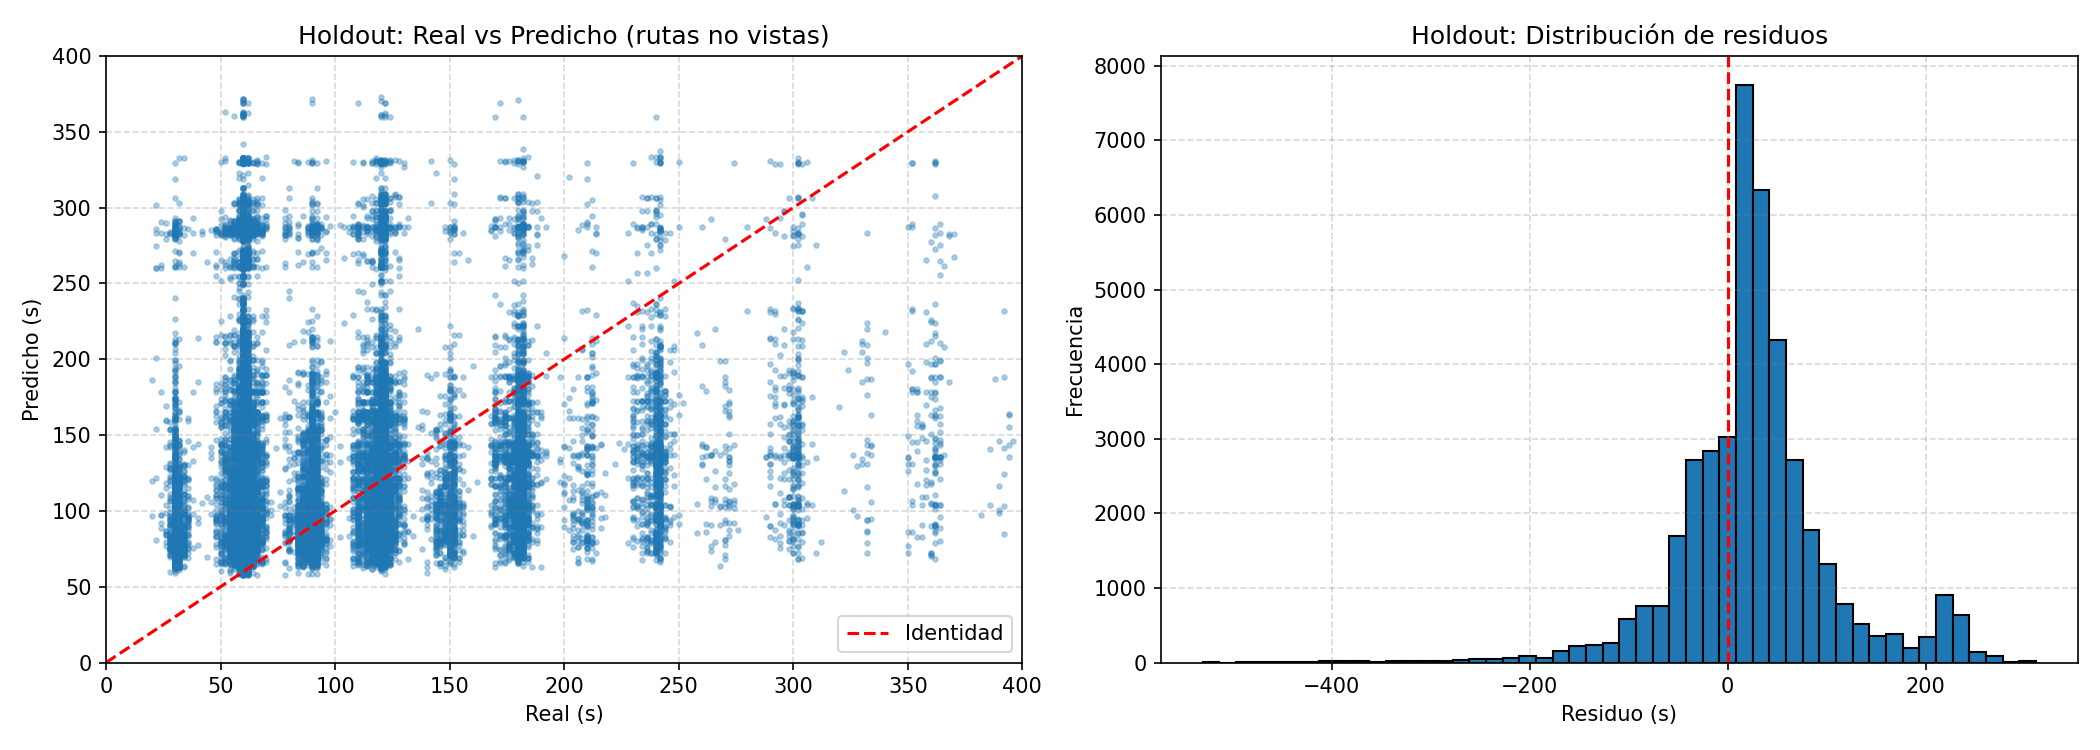

In [18]:
if holdout_diag_path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(holdout_diag_path)))
else:
    print("Run scripts/08_holdout_eval.py first.")

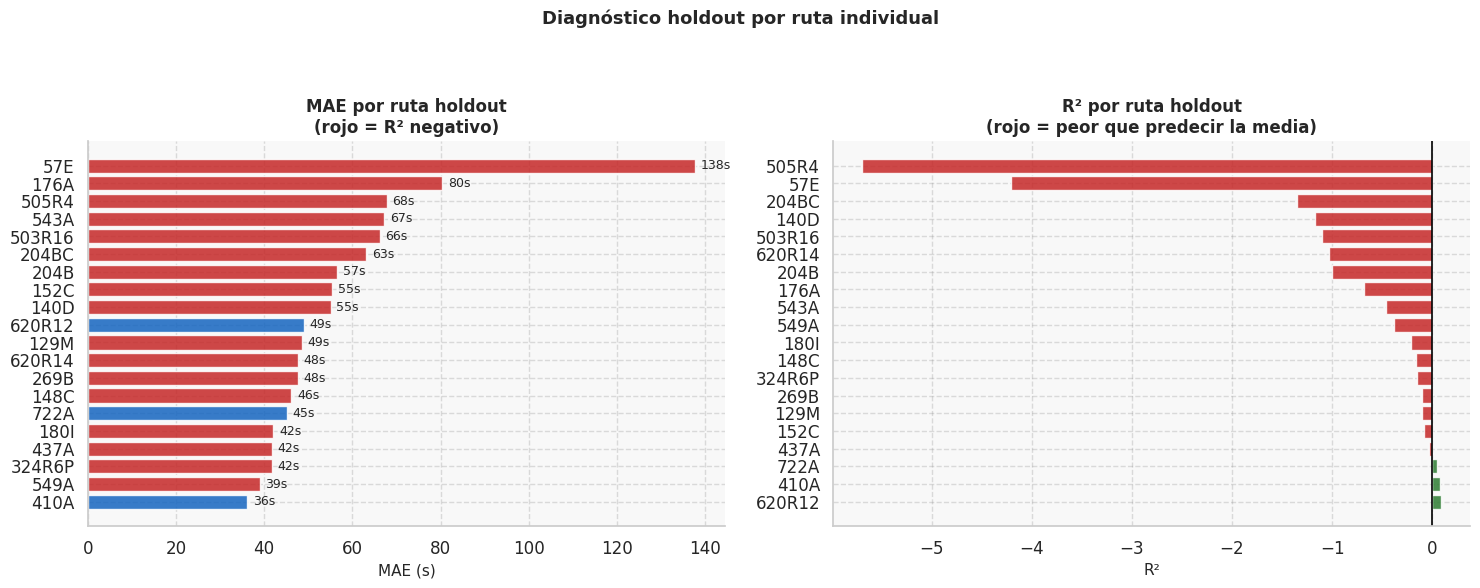


17 rutas con R² negativo:
route_short_name        MAE        R2      n
             57E 137.631959 -4.208569 2701.0
            176A  80.360740 -0.677027 2399.0
           505R4  67.820098 -5.697605  249.0
            543A  67.239040 -0.464674 3619.0
          503R16  66.243850 -1.100548 3377.0
           204BC  63.129902 -1.352137 4528.0
            204B  56.579549 -1.000532  408.0
            152C  55.394952 -0.079992  892.0
            140D  55.052971 -1.175604 3347.0
            129M  48.532669 -0.099184  845.0
          620R14  47.702375 -1.030508  666.0
            269B  47.569842 -0.105460 4560.0
            148C  46.170304 -0.162675 2130.0
            180I  42.090799 -0.206683 1366.0
            437A  41.805973 -0.026814 2231.0
          324R6P  41.742908 -0.151458 2472.0
            549A  38.972288 -0.385549 1039.0


In [19]:
# Desglose de error por ruta holdout — explica el R² global
if holdout_metrics_path.exists():
    _hsf = load_parquet('holdout_segments.parquet')
    if not _hsf.empty:
        _model  = joblib.load(OUTPUTS / "model_travel_time.joblib")
        _feats  = _model["features"]
        _df     = _hsf.copy()
        _hmap   = {"early_morning":0,"morning_peak":1,"midday":2,"evening_peak":3,"night":4}
        _dmap   = {"weekday":0,"weekend":1}
        if "hour_bin" in _df.columns:    _df["hour_bin"] = _df["hour_bin"].map(_hmap).fillna(2)
        if "day_type" in _df.columns:    _df["day_type"] = _df["day_type"].map(_dmap).fillna(0)
        if "pct_semaphores_operational" in _df.columns:
            _df["pct_semaphores_operational"] = _df["pct_semaphores_operational"].fillna(0.0)
        if "n_semaphores" in _df.columns:
            _df["n_semaphores"] = _df["n_semaphores"].fillna(0)

        _avail = [c for c in _feats if c in _df.columns]
        _eval  = _df.dropna(subset=_avail + ["travel_time_observed"]).copy()
        if not _eval.empty:
            from sklearn.metrics import r2_score as _r2s, mean_absolute_error as _mae_fn
            _eval["_pred"] = _model["model"].predict(_eval[_avail].values)
            _eval["_err"]  = (_eval["_pred"] - _eval["travel_time_observed"]).abs()

            _stats = (_eval.groupby("route_short_name")
                      .apply(lambda g: pd.Series({
                          "MAE": g["_err"].mean(),
                          "n":   len(g),
                          "R2":  _r2s(g["travel_time_observed"], g["_pred"]) if len(g)>5 else float('nan'),
                      }), include_groups=False).reset_index()
                      .sort_values("MAE", ascending=False))

            fig, axes = plt.subplots(1, 2, figsize=(15, 6))

            _colors_mae = [PALETTE['danger'] if r2 < 0 else PALETTE['primary']
                           for r2 in _stats['R2']]
            _bars = axes[0].barh(_stats['route_short_name'], _stats['MAE'],
                                  color=_colors_mae, alpha=0.85)
            axes[0].bar_label(_bars, fmt='%.0fs', padding=4, fontsize=9)
            axes[0].set_xlabel('MAE (s)', fontsize=11)
            axes[0].set_title('MAE por ruta holdout\n(rojo = R\u00b2 negativo)',
                               fontsize=12, fontweight='bold')
            axes[0].invert_yaxis(); add_grid(axes[0])

            _r2s_sorted = _stats.sort_values('R2')
            _colors_r2  = [PALETTE['danger'] if r2 < 0 else PALETTE['success']
                           for r2 in _r2s_sorted['R2']]
            axes[1].barh(_r2s_sorted['route_short_name'], _r2s_sorted['R2'],
                          color=_colors_r2, alpha=0.85)
            axes[1].axvline(0, color='black', linewidth=1.2)
            axes[1].set_xlabel('R\u00b2', fontsize=11)
            axes[1].set_title('R\u00b2 por ruta holdout\n(rojo = peor que predecir la media)',
                               fontsize=12, fontweight='bold')
            axes[1].invert_yaxis(); add_grid(axes[1])

            plt.suptitle('Diagnóstico holdout por ruta individual',
                         fontsize=13, fontweight='bold')
            plt.tight_layout(rect=[0, 0, 1, 0.93]); plt.show()

            _neg = _stats[_stats['R2'] < 0][['route_short_name','MAE','R2','n']]
            if not _neg.empty:
                print(f"\n{len(_neg)} rutas con R\u00b2 negativo:")
                print(_neg.to_string(index=False))


### Simulador sobre la peor ruta del holdout

Ejecutamos el simulador de rutas sobre la **peor ruta del holdout** — una ruta que el modelo nunca vio durante el entrenamiento. Esto demuestra que el pipeline funciona en rutas completamente nuevas.

In [20]:
if holdout_metrics_path.exists() and holdout_segs_path.exists():
    with open(holdout_metrics_path) as f:
        hm = json.load(f)
    worst_holdout = hm['worst_route']
    holdout_routes = hm['holdout_routes']

    hsf = load_parquet('holdout_segments.parquet')
    if hsf.empty:
        print('No holdout segments data.')
    else:
        r_data = hsf[(hsf['route_short_name'] == worst_holdout) & hsf['stop_A_lat'].notna()]
        if r_data.empty:
            r_data = hsf[hsf['stop_A_lat'].notna()]
            worst_holdout = r_data['route_short_name'].value_counts().index[0]
            r_data = r_data[r_data['route_short_name'] == worst_holdout]

        best_trip = r_data.groupby('trip_id').size().sort_values(ascending=False).index[0]
        trip_data = r_data[r_data['trip_id'] == best_trip]

        stops_seq_ho = trip_data.groupby('arrival_seq').agg(
            stop_id=('stop_id_A', 'first'), lat=('stop_A_lat', 'median'), lon=('stop_A_lon', 'median'),
        ).sort_index().reset_index(drop=True)

        seg_stats_ho = trip_data[trip_data['next_seq'] == trip_data['arrival_seq'] + 1].groupby(
            'arrival_seq'
        ).agg(
            med_tt=('travel_time_observed', 'median'),
            med_dist=('distance_m', 'median'),
        ).sort_index().reset_index(drop=True)

        total_tt_ho = seg_stats_ho['med_tt'].sum()
        print(f'Holdout worst route: {worst_holdout}')
        print(f'  {len(stops_seq_ho)} paradas, {seg_stats_ho["med_dist"].sum():.0f}m totales')
        print(f'  Tiempo total observado: {total_tt_ho:.0f}s ({total_tt_ho/60:.1f} min)')

        # Build graph using ALL segments (train + holdout) for connectivity
        sf_all = load_parquet('segments_features.parquet')
        sf_combined = pd.concat([sf_all[['stop_id_A','stop_id_B','stop_A_lat','stop_A_lon','stop_B_lat','stop_B_lon','travel_time_observed','route_short_name']],
                                 hsf[['stop_id_A','stop_id_B','stop_A_lat','stop_A_lon','stop_B_lat','stop_B_lon','travel_time_observed','route_short_name']]])

        all_a = sf_combined[['stop_id_A','stop_A_lat','stop_A_lon']].dropna().drop_duplicates('stop_id_A')
        all_a.columns = ['stop_id','lat','lon']
        all_b = sf_combined[['stop_id_B','stop_B_lat','stop_B_lon']].dropna().drop_duplicates('stop_id_B')
        all_b.columns = ['stop_id','lat','lon']
        all_stops = pd.concat([all_a, all_b]).drop_duplicates('stop_id')

        bbox_lat = (stops_seq_ho['lat'].min()-0.015, stops_seq_ho['lat'].max()+0.015)
        bbox_lon = (stops_seq_ho['lon'].min()-0.015, stops_seq_ho['lon'].max()+0.015)
        nearby_ho = all_stops[all_stops['lat'].between(*bbox_lat) & all_stops['lon'].between(*bbox_lon)]
        stop_routes_ho = sf_combined.dropna(subset=['stop_A_lat']).groupby('stop_id_A')[
            'route_short_name'].apply(lambda x: list(x.unique())[:5]).to_dict()

        graph_edges = sf_combined.dropna(subset=['stop_A_lat']).groupby(['stop_id_A','stop_id_B']).agg(
            med_tt=('travel_time_observed','median'), n=('travel_time_observed','count'),
        ).reset_index()
        graph_edges = graph_edges[graph_edges['n'] >= 3]
        zone_ids = set(nearby_ho['stop_id'])
        ze = graph_edges[graph_edges['stop_id_A'].isin(zone_ids) & graph_edges['stop_id_B'].isin(zone_ids)]

        bus_graph_ho = nx.DiGraph()
        for _, r in ze.iterrows():
            bus_graph_ho.add_edge(r['stop_id_A'], r['stop_id_B'], weight=r['med_tt'])

        route_stop_ids_ho = set(stops_seq_ho['stop_id'])
        coords = np.radians(nearby_ho[['lat','lon']].values)
        tree = cKDTree(coords)
        radius_rad = (MAX_GAP_M * 2) / 6_371_000
        pairs = tree.query_pairs(radius_rad)
        for i, j in pairs:
            s, t = nearby_ho.iloc[i], nearby_ho.iloc[j]
            if s['stop_id'] in route_stop_ids_ho and t['stop_id'] in route_stop_ids_ho:
                continue
            if not bus_graph_ho.has_edge(s['stop_id'], t['stop_id']):
                d = haversine_m(s['lat'], s['lon'], t['lat'], t['lon'])
                bus_graph_ho.add_edge(s['stop_id'], t['stop_id'], weight=d/MEDIAN_SPEED)
                bus_graph_ho.add_edge(t['stop_id'], s['stop_id'], weight=d/MEDIAN_SPEED)

        print(f'  Grafo: {bus_graph_ho.number_of_nodes()} nodos, {bus_graph_ho.number_of_edges()} aristas')

        # Find bottlenecks and propose alternatives
        p90_ho = seg_stats_ho['med_tt'].quantile(0.85)
        mean_speed_ho = seg_stats_ho['med_dist'].sum() / seg_stats_ho['med_tt'].sum()

        zones_ho = []
        i = 0
        while i < len(seg_stats_ho):
            if seg_stats_ho.iloc[i]['med_tt'] > p90_ho:
                start = i
                while i < len(seg_stats_ho) and seg_stats_ho.iloc[i]['med_tt'] > p90_ho * 0.6:
                    i += 1
                end = min(i, len(seg_stats_ho))
                if end - start >= 1:
                    zt = seg_stats_ho.iloc[start:end]['med_tt'].sum()
                    zd = seg_stats_ho.iloc[start:end]['med_dist'].sum()
                    expected = zd / mean_speed_ho
                    if zt > expected * 1.3 and zt > 120:
                        zones_ho.append({'start': start, 'end': end, 'tt': zt, 'dist': zd})
            else:
                i += 1

        all_stops_map_ho = nearby_ho.set_index('stop_id')[['lat','lon']].to_dict('index')
        proposals_ho = []
        for z in zones_ho:
            a = stops_seq_ho.iloc[z['start']]
            b = stops_seq_ho.iloc[z['end']]
            try:
                path = nx.shortest_path(bus_graph_ho, a['stop_id'], b['stop_id'], weight='weight')
                path_tt = sum(bus_graph_ho[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            except (nx.NetworkXNoPath, KeyError):
                path = [a['stop_id'], b['stop_id']]
                path_tt = z['tt']

            removed = [stops_seq_ho.iloc[idx]['stop_id'] for idx in range(z['start']+1, z['end'])]
            new_stops = []
            for sid in path[1:-1]:
                info = all_stops_map_ho.get(sid)
                if info:
                    new_stops.append({'stop_id': sid, 'lat': info['lat'], 'lon': info['lon'],
                                      'lines': stop_routes_ho.get(sid, [])[:5],
                                      'is_new': sid not in route_stop_ids_ho})

            all_pts = [(a['lat'], a['lon'])] + [(ns['lat'], ns['lon']) for ns in new_stops] + [(b['lat'], b['lon'])]
            extra = []
            for idx in range(len(all_pts)-1):
                gap = haversine_m(all_pts[idx][0], all_pts[idx][1], all_pts[idx+1][0], all_pts[idx+1][1])
                if gap > MAX_GAP_M:
                    mid = ((all_pts[idx][0]+all_pts[idx+1][0])/2, (all_pts[idx][1]+all_pts[idx+1][1])/2)
                    close = nearby_ho[(abs(nearby_ho['lat']-mid[0])<0.003) & (abs(nearby_ho['lon']-mid[1])<0.003)
                                      & (~nearby_ho['stop_id'].isin(route_stop_ids_ho))]
                    if not close.empty:
                        c = close.iloc[0]
                        extra.append({'stop_id': c['stop_id'], 'lat': c['lat'], 'lon': c['lon'],
                                      'lines': stop_routes_ho.get(c['stop_id'], [])[:5], 'gap': gap})

            max_gap = max(haversine_m(all_pts[i][0], all_pts[i][1], all_pts[i+1][0], all_pts[i+1][1])
                          for i in range(len(all_pts)-1))

            path_geometry = [[all_stops_map_ho[sid]['lon'], all_stops_map_ho[sid]['lat']]
                               for sid in path if sid in all_stops_map_ho]

            proposals_ho.append({
                'zone': f"seq {z['start']}->{z['end']}", 'stop_A': a['stop_id'], 'stop_B': b['stop_id'],
                'lat_A': a['lat'], 'lon_A': a['lon'], 'lat_B': b['lat'], 'lon_B': b['lon'],
                'original_tt': z['tt'], 'original_dist': z['dist'],
                'removed': removed, 'new_stops': new_stops, 'extra': extra,
                'alt_tt': path_tt, 'savings': max(0, z['tt'] - path_tt), 'max_gap': max_gap,
                'path_geometry': path_geometry,
            })

            print(f"Zona {proposals_ho[-1]['zone']}: {a['stop_id']} -> {b['stop_id']}")
            print(f"  Problema: {z['tt']:.0f}s en {z['dist']:.0f}m")
            print(f"  Tiempo: {z['tt']:.0f}s -> {path_tt:.0f}s (ahorro {proposals_ho[-1]['savings']:.0f}s)")

        total_savings_ho = sum(p['savings'] for p in proposals_ho)
        print(f"\nAHORRO TOTAL: {total_savings_ho:.0f}s ({total_savings_ho/60:.1f} min) — {total_savings_ho/total_tt_ho*100:.1f}%")
else:
    print('Run scripts/08_holdout_eval.py first.')

Holdout worst route: 152C
  60 paradas, 19161m totales
  Tiempo total observado: 6103s (101.7 min)
  Grafo: 6555 nodos, 809036 aristas
Zona seq 0->1: 2032045 -> 20837
  Problema: 182s en 342m
  Tiempo: 182s -> 89s (ahorro 93s)
Zona seq 13->20: 205488 -> 205859
  Problema: 1148s en 2312m
  Tiempo: 1148s -> 294s (ahorro 854s)
Zona seq 30->33: 203299 -> 202777
  Problema: 410s en 971m
  Tiempo: 410s -> 130s (ahorro 280s)
Zona seq 43->45: 203918 -> 207528
  Problema: 478s en 598m
  Tiempo: 478s -> 62s (ahorro 416s)
Zona seq 49->51: 204764 -> 204590
  Problema: 358s en 510m
  Tiempo: 358s -> 126s (ahorro 232s)
Zona seq 54->55: 20472 -> 207267
  Problema: 180s en 404m
  Tiempo: 180s -> 62s (ahorro 118s)

AHORRO TOTAL: 1992s (33.2 min) — 32.6%


  Grafo: 6555 nodos, 809036 aristas
Zona seq 0->1: 2032045 -> 20837
  Problema: 182s en 342m
  Tiempo: 182s -> 89s (ahorro 93s)
Zona seq 13->20: 205488 -> 205859
  Problema: 1148s en 2312m
  Tiempo: 1148s -> 294s (ahorro 854s)
Zona seq 30->33: 203299 -> 202777
  Problema: 410s en 971m
  Tiempo: 410s -> 130s (ahorro 280s)
Zona seq 43->45: 203918 -> 207528
  Problema: 478s en 598m
  Tiempo: 478s -> 62s (ahorro 416s)
Zona seq 49->51: 204764 -> 204590
  Problema: 358s en 510m
  Tiempo: 358s -> 126s (ahorro 232s)
Zona seq 54->55: 20472 -> 207267
  Problema: 180s en 404m
  Tiempo: 180s -> 62s (ahorro 118s)

AHORRO TOTAL: 1992s (33.2 min) — 32.6%


In [21]:
if 'proposals_ho' in dir() and proposals_ho and len(stops_seq_ho) > 0:
    _center = [stops_seq_ho['lat'].mean(), stops_seq_ho['lon'].mean()]
    _m = folium.Map(location=_center, zoom_start=14, tiles='CartoDB positron')

    _stop_wpts_ho = [(r['lon'], r['lat']) for _, r in stops_seq_ho.iterrows()]
    from osrm_routing import get_route_waypoints, DEFAULT_OSRM_URL, PUBLIC_OSRM_URL
    _osrm_url_r = DEFAULT_OSRM_URL if ('use_osrm' in dir() and use_osrm) else PUBLIC_OSRM_URL
    _routed_cur = get_route_waypoints(_stop_wpts_ho, osrm_url=_osrm_url_r, timeout=20.0)
    if _routed_cur and _routed_cur.get('geometry'):
        _route_coords = [[pt[1], pt[0]] for pt in _routed_cur['geometry']]
    else:
        _route_coords = [[r['lat'], r['lon']] for _, r in stops_seq_ho.iterrows()]
    folium.PolyLine(_route_coords, color=PALETTE['primary'], weight=5, opacity=0.65,
                    tooltip=f'Ruta actual {worst_holdout}').add_to(_m)
    for _, _row in stops_seq_ho.iterrows():
        folium.CircleMarker([_row['lat'], _row['lon']], radius=4,
                            color=PALETTE['primary'], fill=True,
                            fill_color=PALETTE['primary'], fill_opacity=0.8).add_to(_m)

    for _p in proposals_ho:
        _iA = stops_seq_ho[stops_seq_ho['stop_id'] == _p['stop_A']].index
        _iB = stops_seq_ho[stops_seq_ho['stop_id'] == _p['stop_B']].index
        if len(_iA) and len(_iB):
            _zone = stops_seq_ho.iloc[_iA[0]:_iB[0]+1]
            folium.PolyLine([[r['lat'], r['lon']] for _, r in _zone.iterrows()],
                            color=PALETTE['danger'], weight=10, opacity=0.35,
                            tooltip='\u26a0 Zona congestionada').add_to(_m)

        for _sid in _p['removed']:
            _mr = stops_seq_ho[stops_seq_ho['stop_id'] == _sid]
            if not _mr.empty:
                _r = _mr.iloc[0]
                folium.CircleMarker([_r['lat'], _r['lon']], radius=9,
                                    color=PALETTE['danger'], fill=True,
                                    fill_color=PALETTE['danger'], fill_opacity=0.9,
                                    tooltip=f'\u26d4 Eliminar: {_sid}').add_to(_m)

        if _p.get('path_geometry') and len(_p['path_geometry']) > 1:
            _alt = [[pt[1], pt[0]] for pt in _p['path_geometry']]
        else:
            _alt = ([[_p['lat_A'], _p['lon_A']]]
                    + [[ns['lat'], ns['lon']] for ns in _p['new_stops']]
                    + [[es['lat'], es['lon']] for es in _p['extra']]
                    + [[_p['lat_B'], _p['lon_B']]])
        folium.PolyLine(_alt, color=PALETTE['success'], weight=5, opacity=0.9,
                        tooltip=f"\u2705 Alternativa: -{_p['savings']:.0f}s").add_to(_m)

        for _ns in _p['new_stops']:
            _c = PALETTE['success'] if _ns['is_new'] else '#42A5F5'
            folium.CircleMarker([_ns['lat'], _ns['lon']], radius=8,
                                color=_c, fill=True, fill_color=_c, fill_opacity=0.9,
                                tooltip=f"{' '.join([chr(11088)+' Nueva:'] + _ns['lines'][:2]) if _ns['is_new'] else 'existente'}").add_to(_m)
        for _es in _p['extra']:
            folium.CircleMarker([_es['lat'], _es['lon']], radius=8,
                                color=PALETTE['warning'], fill=True,
                                fill_color=PALETTE['warning'], fill_opacity=0.9,
                                tooltip=f"Intermedia: {_es['stop_id']}").add_to(_m)

        _mid_lat = (_p['lat_A'] + _p['lat_B']) / 2 + 0.001
        _mid_lon = (_p['lon_A'] + _p['lon_B']) / 2
        folium.Marker([_mid_lat, _mid_lon], icon=folium.DivIcon(
            html=(f'<div style="background:white;border:2px solid {PALETTE["success"]};'
                  f'padding:4px 8px;border-radius:5px;font-size:12px;font-weight:bold;'
                  f'color:{PALETTE["success"]};white-space:nowrap;box-shadow:1px 1px 4px #aaa">'
                  f'-{_p["savings"]:.0f}s ({_p["savings"]/60:.1f} min)</div>'),
            icon_size=(150, 28), icon_anchor=(75, 0),
        )).add_to(_m)

    _legend = f"""
    <div style="position:fixed;bottom:30px;left:30px;z-index:9999;background:white;
                padding:12px 16px;border-radius:8px;border:1px solid #ccc;
                font-size:13px;line-height:2;box-shadow:2px 2px 6px #aaa">
      <b>Linea {worst_holdout}</b><br>
      <span style="color:{PALETTE['primary']}">&#9644;</span> Ruta actual &nbsp;
      <span style="color:{PALETTE['danger']}">&#9644;</span> Zona congestionada<br>
      <span style="color:{PALETTE['success']}">&#9644;</span> Ruta alternativa &nbsp;
      <span style="color:{PALETTE['danger']}">&#9679;</span> Eliminar &nbsp;
      <span style="color:{PALETTE['success']}">&#9679;</span> Nueva
    </div>"""
    _m.get_root().html.add_child(folium.Element(_legend))
    print(f"Linea {worst_holdout} | {len(proposals_ho)} zona(s) | Ahorro total: {total_savings_ho:.0f}s ({total_savings_ho/60:.1f} min)")
    display(_m)
else:
    print("Ejecutar celda anterior primero.")


Linea 152C | 6 zona(s) | Ahorro total: 1992s (33.2 min)


## Conclusiones

**Preparación** — Features de distancia, zona geográfica, franja horaria y semáforos (solo CABA). Codificación numérica de categorías sobre el pipeline del TP anterior.

**Modelos** — Random Forest, XGBoost, Gradient Boosting

**Hiperparámetros** — `GridSearchCV` 3-fold sobre grids de `n_estimators`, `max_depth` y `learning_rate`.

**Resultados**
- *Travel time*: RF gana con MAE=34.6s y R²=0.43 (+27% vs baseline). En holdout cae a R²=−0.79 — el modelo aprendió patrones de rutas específicas y no generaliza bien.
- *Headway*: Gradient Boosting gana con MAE=196s y R²=0.13. R² bajo esperado: el headway real depende de factores operacionales no capturados. Supera ampliamente al GTFS programado (MAE=953s).

**Limitación principal** — Brecha train/holdout indica necesidad de features más generalizables (tráfico por zona) y mayor cobertura de rutas en entrenamiento.
